# Insurance Risk Analytics - EDA

### Import Required Libraries

In [1]:
import sys 
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_3/insurance-risk-analytics'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_3/insurance-risk-analytics'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_3\insurance-risk-analytics


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

from src.data_loader import load_data
from src.data_preprocessor import missing_values, check_dateFormat, missing_values, normalize_date, save_cleaned_data
from src.plots import plot_summarization, plot_policy_distribution, plot_log_summarization, plot_province_vType_claimRate, plot_log_premium_claim_province, plot_corr_numericals, plot_numericals_frequency, plot_categoricals_count, plot_claim_premium, plot_log_claim_premium, plot_diagnostics, plot_lossRatio, plot_diagnostics_row, plot_premium_claim_zipcode, plot_log_premium_claim_severity, plot_diagnostics_vehicleModel, plot_vType_AvePremium_claimRate, plot_box_outliers, plot_box_log_outliers, plot_box_percentile_outliers


## Read the Insurance dataset

In [3]:
df = load_data('../data/MachineLearningRating_v3.txt', sep = '|', parse_dates = ['TransactionMonth'], na_values=[' ', 'Not specified'])

df.head()

Dataset loaded successfully.
Shape: (1000098, 52)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [ ]:
df.describe()

,UnderwrittenCoverID,PolicyID,TransactionMonth,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1000098,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,2015-02-28 10:49:29.147424,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
min,1.000000e+00,1.400000e+01,2013-10-01 00:00:00,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,2015-01-01 00:00:00,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2015-04-01 00:00:00,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,2015-06-01 00:00:00,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,2015-08-01 00:00:00,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05
std,6.329371e+04,5.290039e+03,NaN,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03


In [ ]:
print(df.dtypes)

UnderwrittenCoverID                  int64
PolicyID                             int64
TransactionMonth            datetime64[us]
IsVATRegistered                       bool
Citizenship                            str
LegalType                              str
Title                                  str
Language                               str
Bank                                   str
AccountType                            str
MaritalStatus                          str
Gender                                 str
Country                                str
Province                               str
PostalCode                           int64
MainCrestaZone                         str
SubCrestaZone                          str
ItemType                               str
mmcode                             float64
VehicleType                            str
RegistrationYear                     int64
make                                   str
Model                                  str
Cylinders  

## Data Preprocessing

### Data quality Audit

In [ ]:
missing_values(df)


Removed 1000098 rows with missing data
Remaining: 0


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims


In [ ]:
check_dateFormat(df)

Checking date format:
------------------------------
Sample dates: 2015-03-01 00:00:00
Data type of 'date' column: datetime64[us]
  Target format: YYYY-MM-DD (string or date object)


In [ ]:
print('TransactionMonth')
df = normalize_date(df, 'TransactionMonth')
print('\nRegistrationYear   ')                  
df = normalize_date(df, 'RegistrationYear')
print('\nVehicleIntroDate   ')                    
df = normalize_date(df, 'VehicleIntroDate')

TransactionMonth
Dates normalized
dtype: datetime64[us]

Date range: 2013-10-01 00:00:00 to 2015-08-01 00:00:00

RegistrationYear   
Dates normalized
dtype: datetime64[ns]

Date range: 1970-01-01 00:00:00 to 1970-01-01 00:00:00

VehicleIntroDate   
Dates normalized
dtype: datetime64[us]

Date range: 1977-10-01 00:00:00 to 2014-09-01 00:00:00


In [ ]:
# Number of UnderwrittenCoverID
uwc = df['UnderwrittenCoverID'].value_counts().sort_index(ascending=True)
print("=== Number of UnderwrittenCoverID ===")
print(f'Total number of UnderwrittenCoverID: {df['UnderwrittenCoverID'].nunique()}')
print(uwc)

=== Number of UnderwrittenCoverID ===
Total number of UnderwrittenCoverID: 116532
UnderwrittenCoverID
1         12
2         12
3         12
4         12
5         12
          ..
301169     2
301170     2
301173     2
301174     2
301175     2
Name: count, Length: 116532, dtype: int64


In [ ]:
df.groupby('Province')['UnderwrittenCoverID'].nunique()

Province
Eastern Cape      4061
Free State         876
Gauteng          46520
KwaZulu-Natal    22796
Limpopo           2813
Mpumalanga        5406
North West       16322
Northern Cape      825
Western Cape     16923
Name: UnderwrittenCoverID, dtype: int64

In [ ]:
# Number of Policies
policies = df['PolicyID'].value_counts().sort_index(ascending=True)
print("=== Number of Policies ===")
print(f'Total number of Policies: {df['PolicyID'].nunique()}')
print(policies)

=== Number of Policies ===
Total number of Policies: 7000
PolicyID
14       216
15       225
16       108
17       108
18       108
        ... 
23239      8
23241     22
23244     24
23245     22
23246     20
Name: count, Length: 7000, dtype: int64


In [ ]:
df.groupby('Province')['PolicyID'].nunique()

Province
Eastern Cape      319
Free State         54
Gauteng          2578
KwaZulu-Natal    1370
Limpopo           181
Mpumalanga        382
North West       1117
Northern Cape      55
Western Cape      947
Name: PolicyID, dtype: int64

## Descriptive Analytics: "What Happened?"

In [ ]:
# High-Level Metrics
overall_total_premiums = df['TotalPremium'].sum()
overall_total_claims = df['TotalClaims'].sum()

# 2. Get the correct counts for denominators
active_premiums_count = (df['TotalPremium'] != 0).sum()
actual_claims_count = (df['TotalClaims'] > 0).sum()

#overall_claim_rate = df['Claimed'].mean() * 100
overall_loss_ratio = (overall_total_claims / overall_total_premiums) * 100
margin = overall_total_premiums - overall_total_claims
# Profit margin as a true percentage of revenue
profit_margin_pct = ((overall_total_premiums - overall_total_claims) / overall_total_premiums) * 100
# Average cost only for people who actually made a claim (> 0)
average_claim_cost = overall_total_claims / (df['TotalClaims'] > 0).sum()
# Average premium only for active, paying policyholders (!= 0)
average_premium_cost = overall_total_premiums / (df['TotalPremium'] != 0).sum()

metrics_df = pd.DataFrame({
    'Metric': [
        'Total Premiums Collected',
        'Total Claims Paid',
        'Overall Loss Ratio (%)',
        'Margin',
        'Profit Margin (%)',
        'Average Cost per Claim',
        'Average Premium'
    ],
    'Value': [
        f"${overall_total_premiums:,.2f}",
        f"${overall_total_claims:,.2f}",
        f"{overall_loss_ratio:.2f}%",
        f"{margin:.2f}",
        f"{profit_margin_pct:.2f}%",
        f"${average_claim_cost:,.2f}",
        f"${average_premium_cost:,.2f}"

    ]
})
print("=== Portfolio Summary (Retrospective Overview) ===")
metrics_df

=== Portfolio Summary (Retrospective Overview) ===


,Metric,Value
0,Total Premiums Collected,"$61,911,562.70"
1,Total Claims Paid,"$64,867,546.17"
2,Overall Loss Ratio (%),104.77%
3,Margin,-2955983.47
4,Profit Margin (%),-4.77%
5,Average Cost per Claim,"$23,266.70"
6,Average Premium,$100.11


## Interpretation:

    -   As per the above portfolio summary table, the paid claim amount is greater than the total collected premium amount.

    -   The loss ratio shows that the company is spending more money on paying claims than it is collecting premium.
    
    -   The profit margin shows the company is at 4.77% in loss

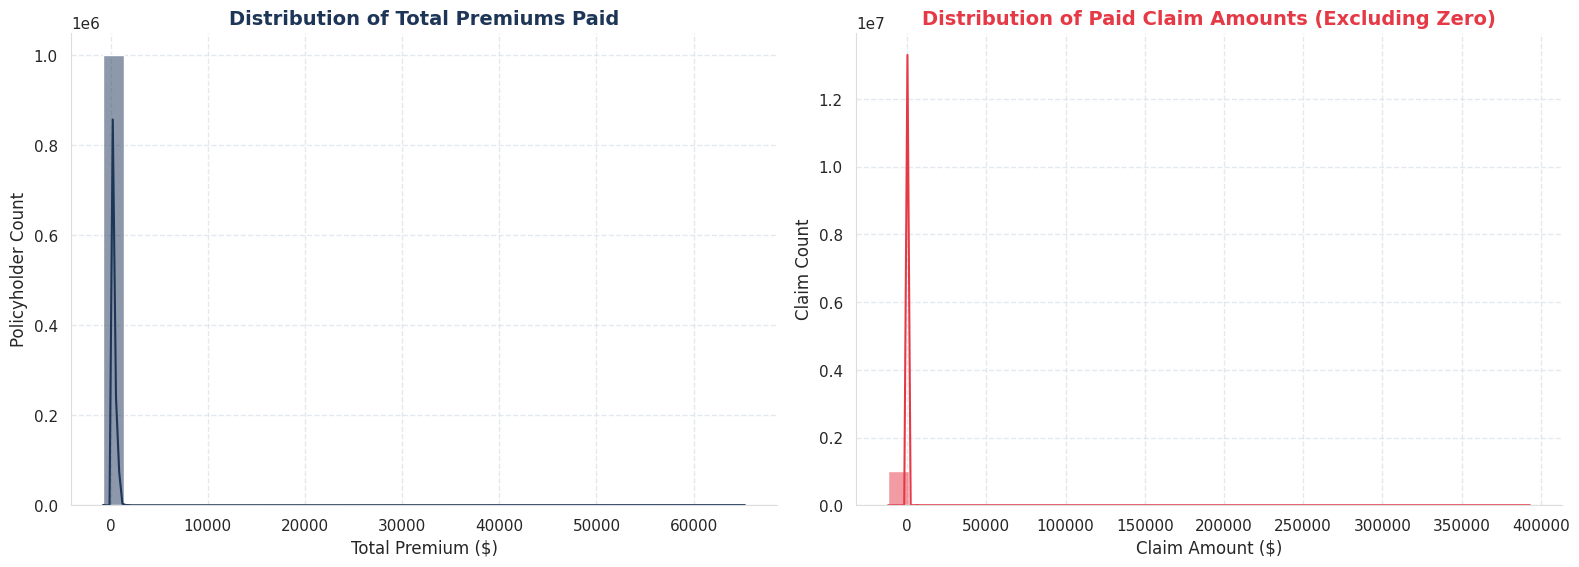

In [ ]:
plot_summarization(df)

## Interpretation:

    The plot is too skewwed to interprete the real information behind it.


## Why too Skewwed?

In [ ]:
# Count the number of zeros in Total premium
zero_count = (df['TotalClaims'] == 0).sum()

# Count the total number of rows in Total Claim
total_count = len(df['TotalClaims'])

print("Total Claim")
print(f"Number of zeros: {zero_count}")
print(f"Total rows: {total_count}")
print(f"Non zero columns: {total_count - zero_count}")
print(f"Min: {df['TotalClaims'].min()}")
print(f"Max: {df['TotalClaims'].max()}")

# Count the number of zeros in Total premium
zero_countp = (df['TotalPremium'] == 0).sum()
# Count the total number of rows in Total premium
total_countp = len(df['TotalPremium'])
print("\nTotal Premium")
print(f"Number of zeros: {zero_countp}")
print(f"Total rows: {total_countp}")
print(f"Non zero columns: {total_countp - zero_countp}")
print(f"min: {df['TotalPremium'].min()}")
print(f"max: {df['TotalPremium'].max()}")

# 1. Filter down to rows where both are exactly 0
both_zero_df = df[(df['TotalClaims'] == 0) & (df['TotalPremium'] == 0)]
premium_not_Claim_df = df[(df['TotalClaims'] > 0) & (df['TotalPremium'] == 0)]
# 2. Use len() on the filtered dataframe to get the row count
count_both_zero = len(both_zero_df)
count_premium_not_Claim = len(premium_not_Claim_df)

# 3. Calculate percentage accurately
pct_both_zero = (count_both_zero / len(df)) * 100

print(f"Count of rows where both Premium and Claims are zero: {count_both_zero:,}")
print(f"Percentage of total rows: {pct_both_zero:.4f}%")


print(f"\nCount of rows where Premium is zero and Claim is requested: {count_premium_not_Claim:,}")

Total Claim
Number of zeros: 997305
Total rows: 1000098
Non zero columns: 2793
Min: -12002.412280701796
Max: 393092.105263158

Total Premium
Number of zeros: 381634
Total rows: 1000098
Non zero columns: 618464
min: -782.576754385965
max: 65282.6034210526
Count of rows where both Premium and Claims are zero: 381,484
Percentage of total rows: 38.1447%

Count of rows where Premium is zero and Claim is requested: 147


## Interpretation

    - Around 38% of our data is has no premium paid and no claim requested. This indicated that the clients either cancelled their subscription or stopped paying.

    - Claim <0: the company actually recovered money on that specific policy account, making it a profitable file for that period.

    - Premium < 0: these entries might be mid term subscription cancellation or coverage reduction which credit the customer.

### Policy Distribution by Premium and Claim

In [ ]:
# Amount of rows with Zero Premium AND Zero Claims
print('Amount of rows with Zero Premium AND Zero Claims')
print(((df['TotalPremium'] == 0) & (df['TotalClaims'] == 0)).sum())

# Amount of rows with Active Premium AND Zero Claims
print('Amount of rows with Active Premium AND Zero Claims')
print(((df['TotalPremium'] > 0) & (df['TotalClaims'] == 0)).sum())

# Amount of rows with Active Premium AND Active Claims
print(' Amount of rows with Active Premium AND Active Claims')
print(((df['TotalPremium'] > 0) & (df['TotalClaims'] > 0)).sum())

# Amount of rows with Zero Premium AND Active Claims
print('Amount of rows with Zero Premium AND Active Claims')
print(((df['TotalPremium'] == 0) & (df['TotalClaims'] > 0)).sum())

Amount of rows with Zero Premium AND Zero Claims
381484
Amount of rows with Active Premium AND Zero Claims
615533
 Amount of rows with Active Premium AND Active Claims
2641
Amount of rows with Zero Premium AND Active Claims
147


{np.int64(381484)}


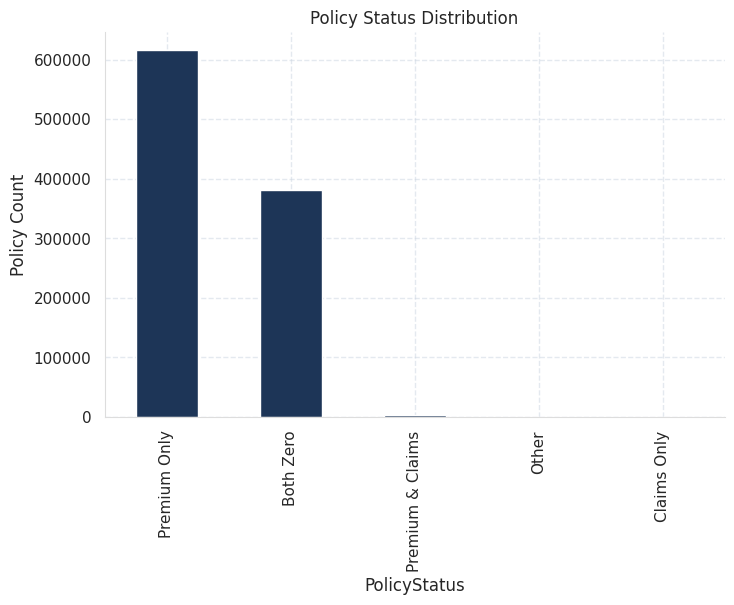

In [ ]:
plot_policy_distribution(df)

## Interpretation:
Data with:

    - both Premium and Claim >0: are the active clients

    - premium > 0 and Claim = 0: Clients who did not request for a claim

    - premium =0 and claim  = 0: are inactive clients, which might stopped their subscription or cancelled it.
    
    - premium = 0 and claim >0 : this is where the suspicion begins, the customers are not thier duty for coverage however they are getting service.


### Dropping data where both Total claim and Total premium = 0

As the clients  stopped their subscription, those are removed as they don't add value to our analysis however dropping them will help us to reduce the zero inflation on our analysis.

In [ ]:
#keep dataset where total claim and total premium are not zero
df_clean = df[~((df['TotalClaims'] == 0) & (df['TotalPremium'] == 0))]

# Verify the new shape
print(f"Original rows: {len(df):,}")
print(f"Cleaned rows:  {len(df_clean):,}")
print(f"Rows dropped:  {len(df) - len(df_clean):,}")



Original rows: 1,000,098
Cleaned rows:  618,614
Rows dropped:  381,484


### To change the too skiwwed in to normal distribution: Log transformation is applied here!

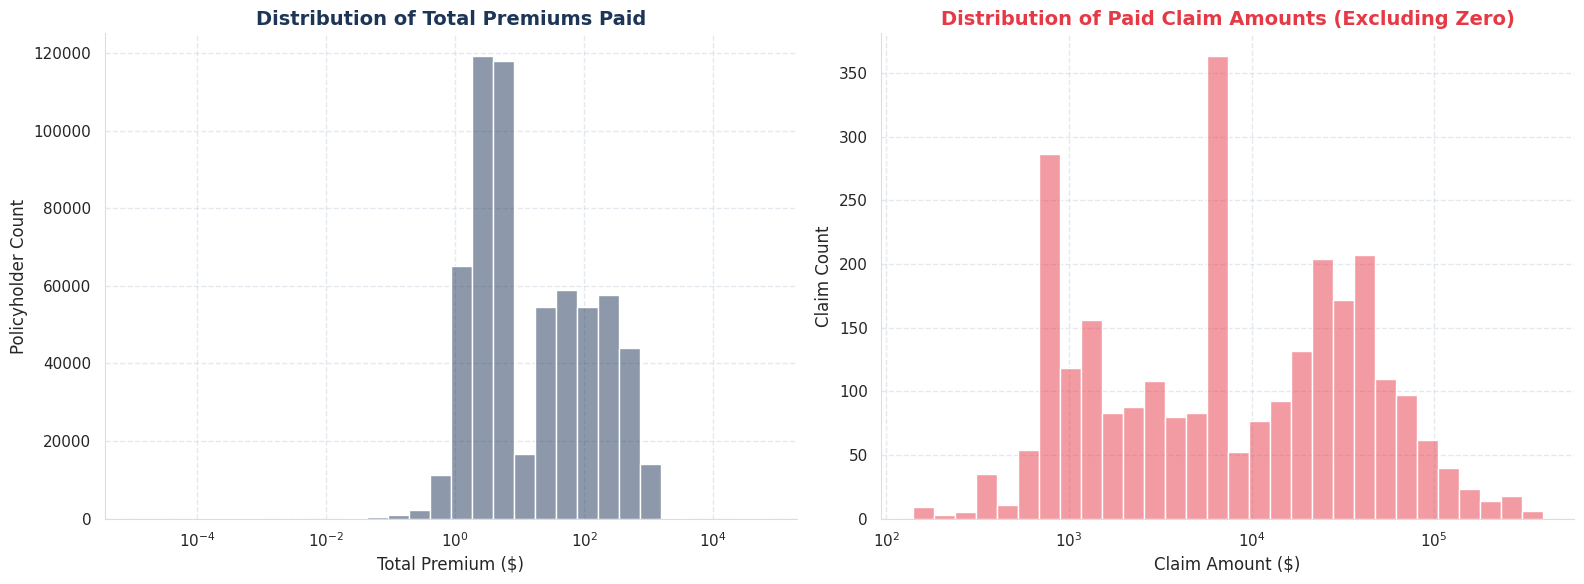

In [ ]:
plot_log_summarization(df_clean)

###  Vehicle Type Analysis

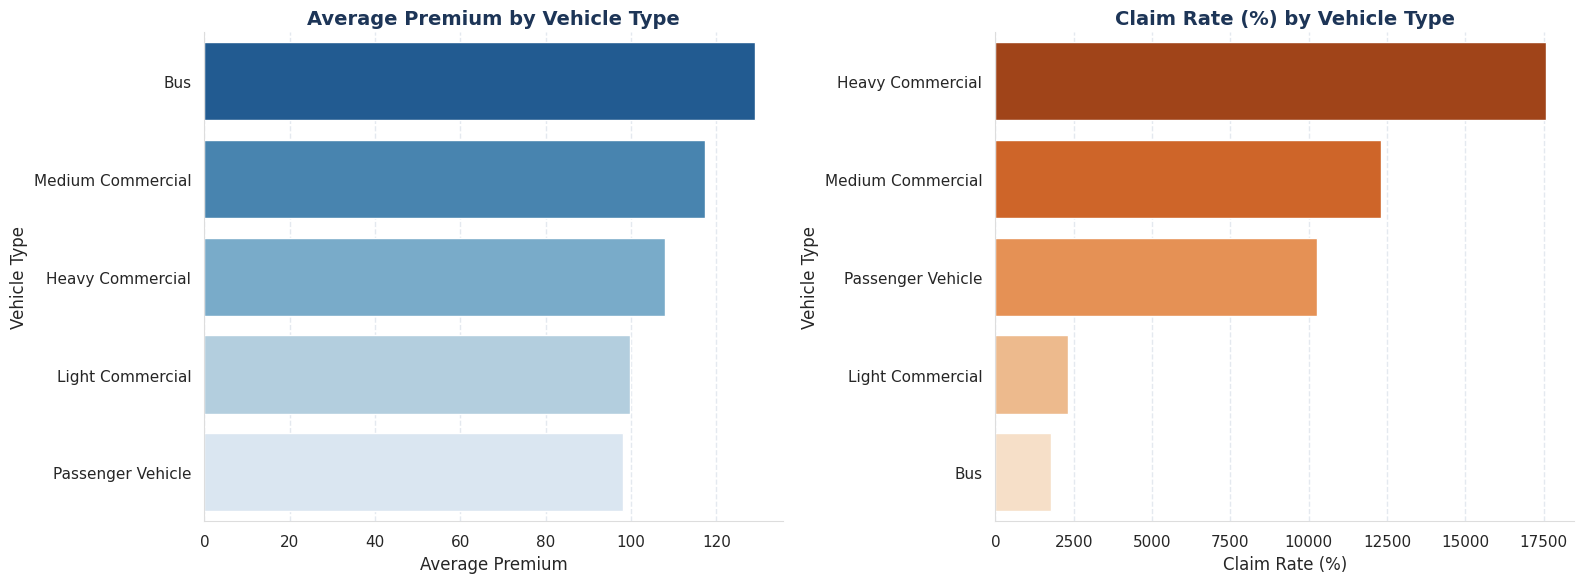

In [ ]:
plot_vType_AvePremium_claimRate(df_clean)

### Interpretation:

    -   The top three top three provinces that has haigher claim frequency might have either a road which is not good for driving or have a higher accident rate.

    -   Heavy Commercial cars are the more prone to accident cars or the more expensive to maintain

## Premium Vs Claim by Province

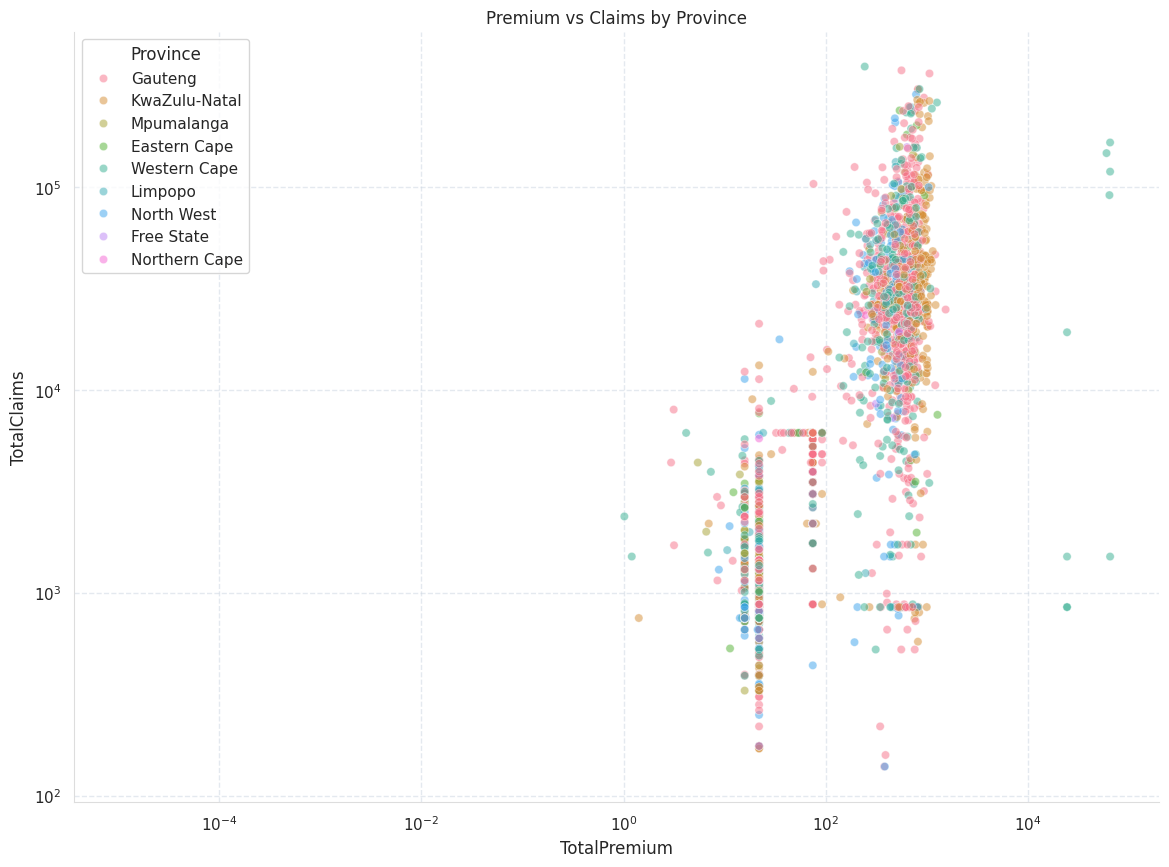

In [ ]:
plot_log_premium_claim_province(df_clean)

Insight:

    -   

## VehicleType Risk

In [ ]:
vtype_risk = df.groupby('VehicleType').agg({'TotalPremium': 'mean','TotalClaims': 'mean'})

print(vtype_risk.sort_values(
    'TotalClaims',
    ascending=False
))

                   TotalPremium  TotalClaims
VehicleType                                 
Heavy Commercial      62.281835   101.401781
Medium Commercial     72.663620    76.315030
Passenger Vehicle     60.670670    63.594898
Light Commercial      66.845656    15.512574
Bus                   87.586075    12.024865


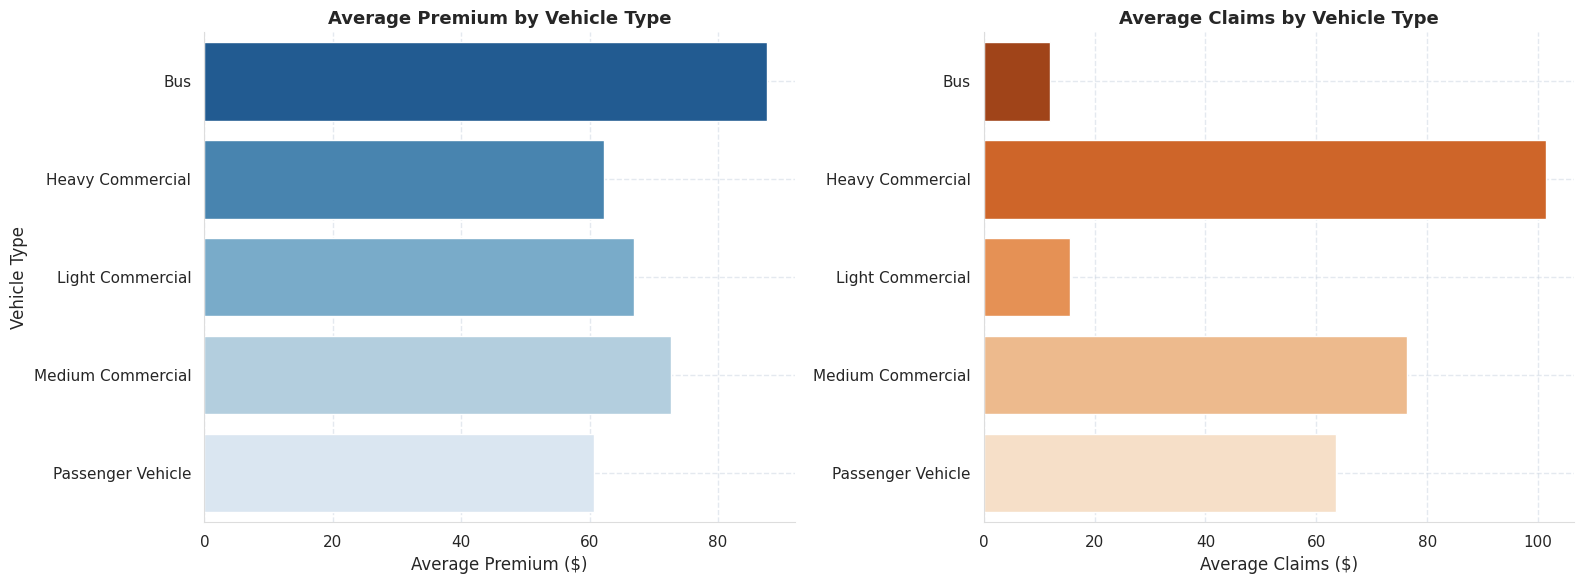

=== Vehicle Type Risk Diagnostics ===
 TotalPremium  TotalClaims
    87.586075    12.024865
    62.281835   101.401781
    66.845656    15.512574
    72.663620    76.315030
    60.670670    63.594898


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Average Premium by Vehicle Type
sns.barplot(
    data=vtype_risk, 
    y='VehicleType', 
    x='TotalPremium', 
    ax=axes[0], 
    palette='Blues_r'  # '_r' reverses the palette so the highest value is darkest
)
axes[0].set_title('Average Premium by Vehicle Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Premium ($)')
axes[0].set_ylabel('Vehicle Type')
axes[0].grid(True, which="both", ls="--", alpha=0.5)

# Right Plot: Average Claims by Vehicle Type (The Sort Metric)
sns.barplot(
    data=vtype_risk, 
    y='VehicleType', 
    x='TotalClaims', 
    ax=axes[1], 
    palette='Oranges_r'
)
axes[1].set_title('Average Claims by Vehicle Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Claims ($)')
axes[1].set_ylabel('')  # Remove redundant label for the right side

# Enforce your global grid style explicitly
axes[1].grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Print the table below the plot as requested
print("=== Vehicle Type Risk Diagnostics ===")
print(vtype_risk.to_string(index=False))

## Loss Ratio by Province

In [ ]:
province_loss = df.groupby('Province').agg({
    'TotalClaims': 'sum',
    'TotalPremium': 'sum'
})

province_loss['LossRatio'] = ( province_loss['TotalClaims'] / province_loss['TotalPremium'])

print(province_loss.sort_values('LossRatio', ascending=False))

                TotalClaims  TotalPremium  LossRatio
Province                                            
Gauteng        2.939415e+07  2.405377e+07   1.222018
KwaZulu-Natal  1.430138e+07  1.320908e+07   1.082693
Western Cape   1.038977e+07  9.806559e+06   1.059472
North West     5.920250e+06  7.490508e+06   0.790367
Mpumalanga     2.044675e+06  2.836292e+06   0.720897
Free State     3.549223e+05  5.213632e+05   0.680758
Limpopo        1.016477e+06  1.537324e+06   0.661199
Eastern Cape   1.356427e+06  2.140104e+06   0.633813
Northern Cape  8.949051e+04  3.165581e+05   0.282699


### Claim Frequency per Policy

In [ ]:
# Total unique policies
total_policies = df_clean['PolicyID'].nunique()

# Policies with claims
policies_with_claims = df_clean[df_clean['TotalClaims'] > 0]['PolicyID'].nunique()

# Claim Frequency
claim_frequency = policies_with_claims / total_policies

print("Total Policies:", total_policies)
print("Policies With Claims:", policies_with_claims)
print("Claim Frequency:", round(claim_frequency, 4))

Total Policies: 5637
Policies With Claims: 1422
Claim Frequency: 0.2523


## Claim Severity - Average Claim paid per claim

In [ ]:
# Total claim amount
total_claim_amount = df_clean['TotalClaims'].sum()

# Number of claims
number_of_claims = (df_clean['TotalClaims'] > 0).sum()

# Claim Severity
claim_severity = total_claim_amount / number_of_claims

print("Total Claim Amount:", total_claim_amount)
print("Number of Claims:", number_of_claims)
print("Claim Severity:", round(claim_severity, 2))

Total Claim Amount: 64867546.17070176
Number of Claims: 2788
Claim Severity: 23266.7


## Diagnostic Analytics: "Why Did It Happen?"

## Univariate Analysis

Purpose:

Understand distributions,
detect skewness,
identify dominant categories,
check data quality.

### Correlation between Numerical Drivers

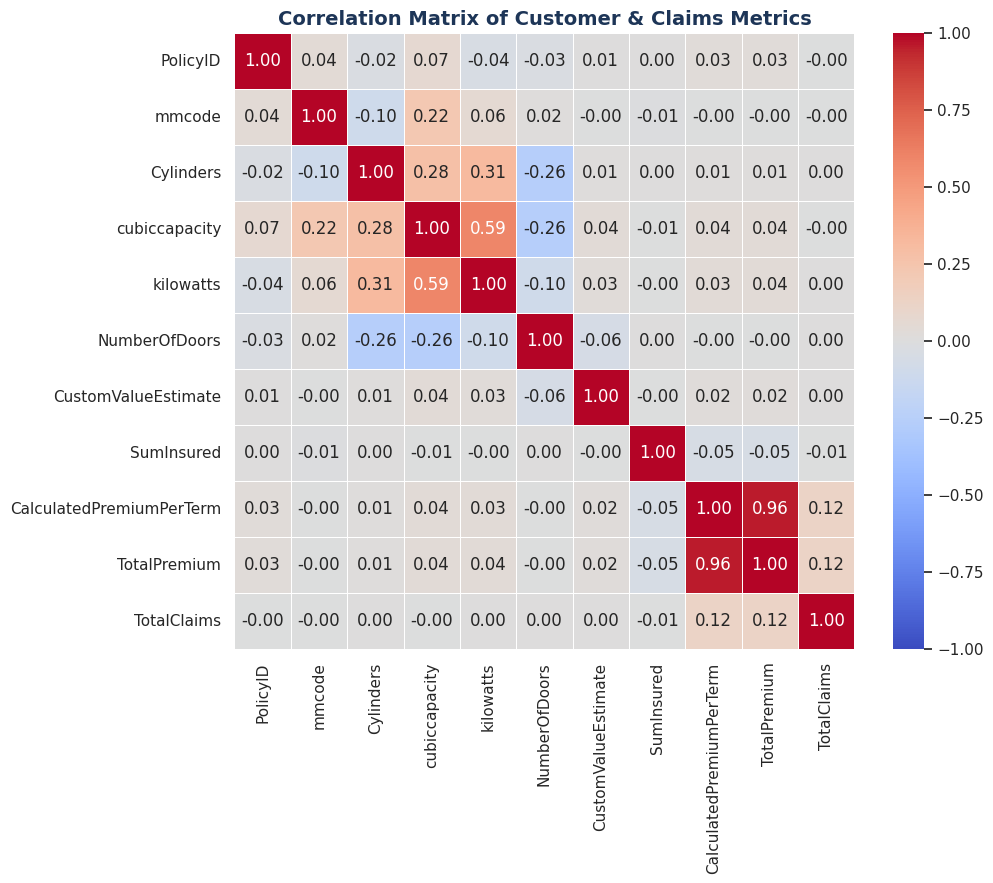

In [ ]:
# Correlation Matrix of Numerical Drivers
numerical_cols = ['PolicyID', 'mmcode', 'Cylinders', 'cubiccapacity', 'kilowatts', 'NumberOfDoors', 'CustomValueEstimate',
                   'SumInsured', 'CalculatedPremiumPerTerm', 'TotalPremium', 'TotalClaims']

plot_corr_numericals(df_clean, numerical_cols)

## Insight:

    -   Cubic capacity is highly related with Kilo watt, Cylinders and MMcode

    -   Kilo watt is highly related with Cylinders

### Numerical Columns Frequency Analysis

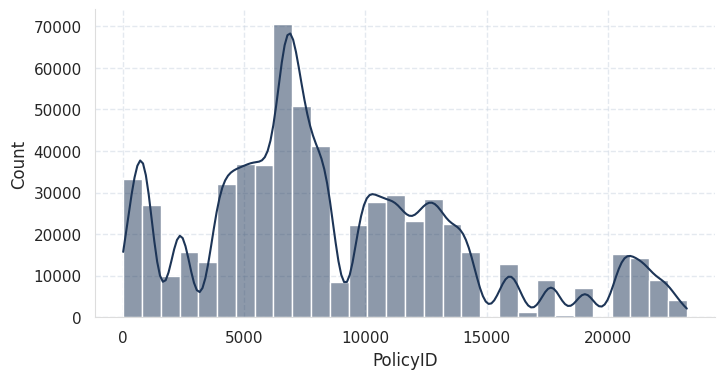

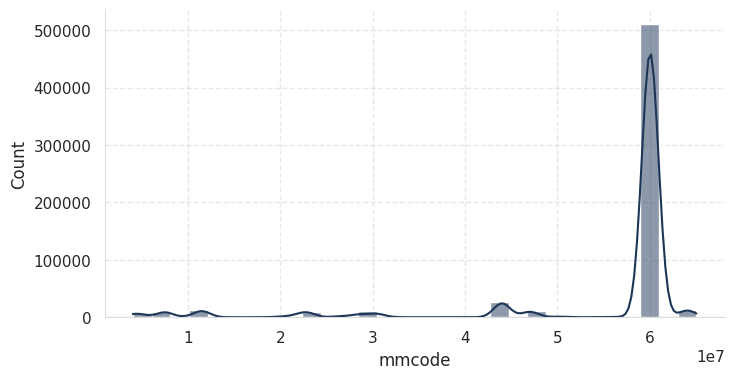

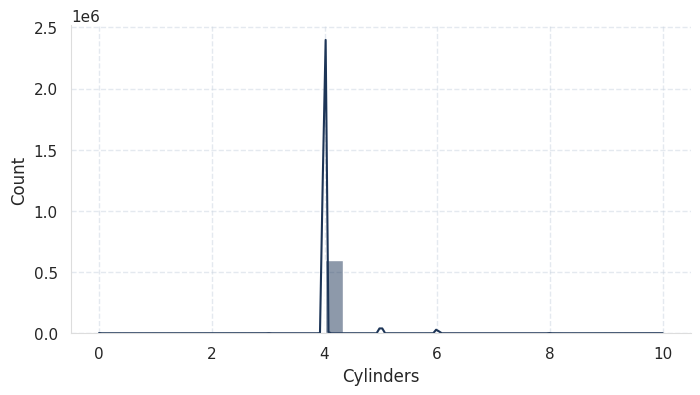

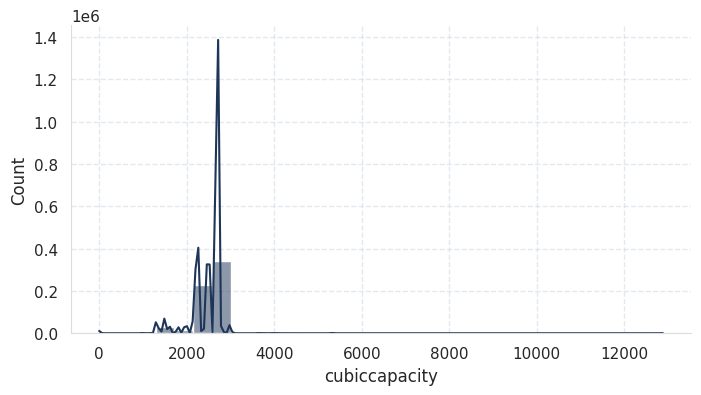

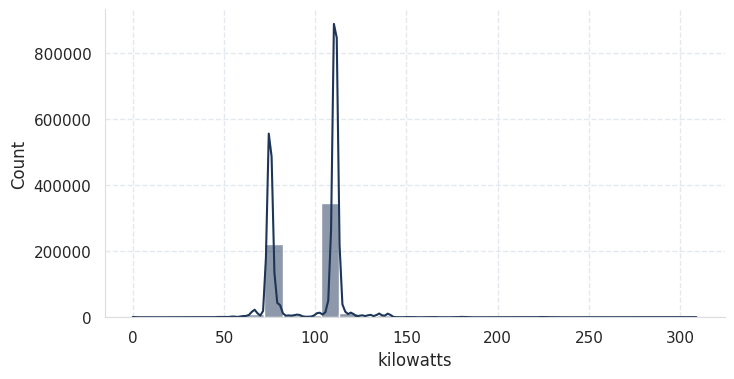

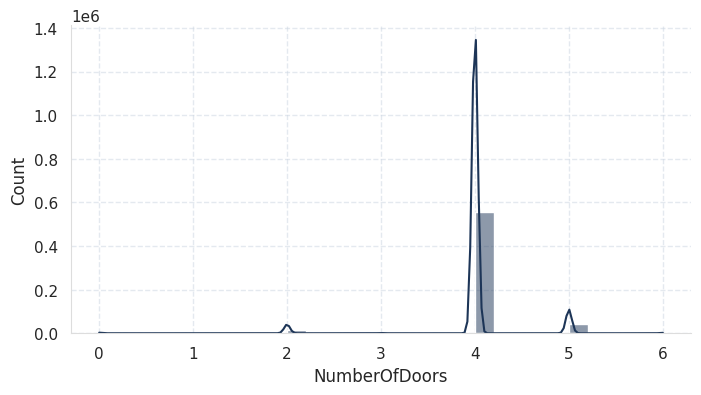

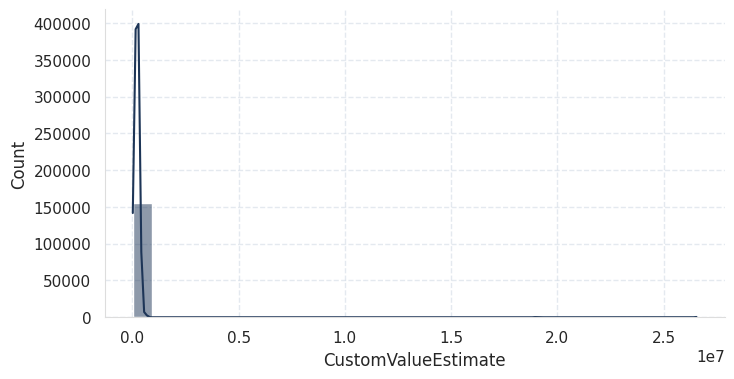

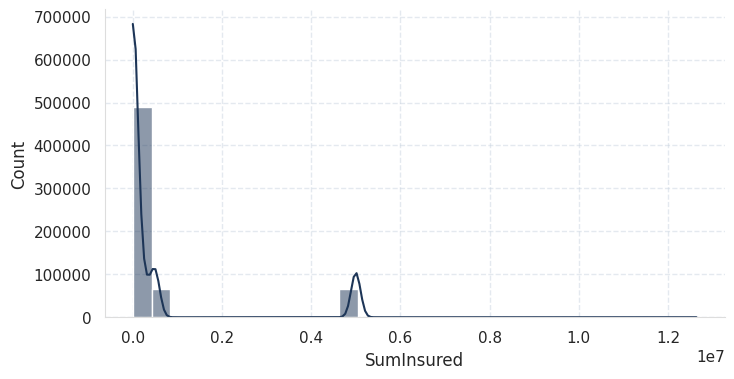

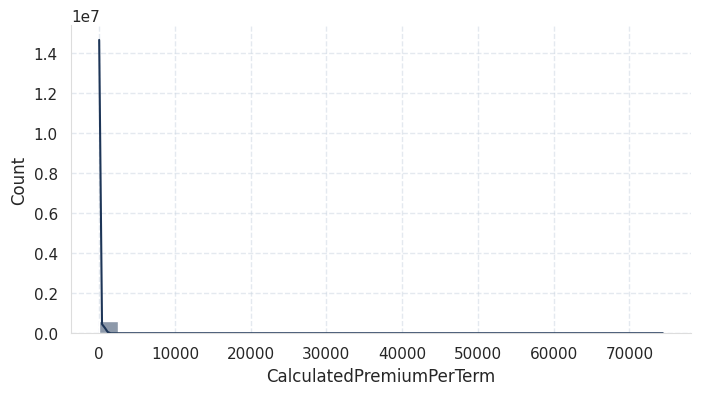

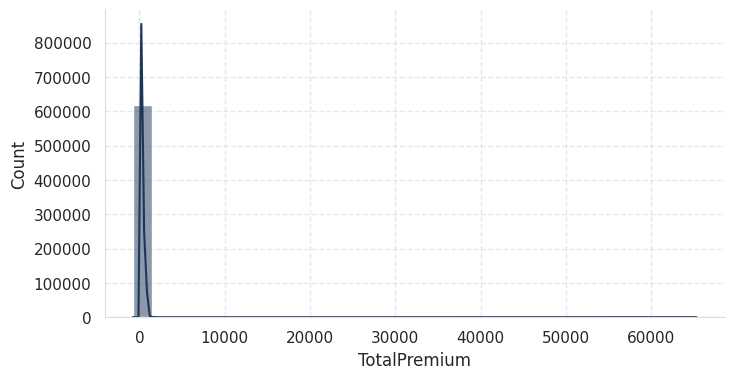

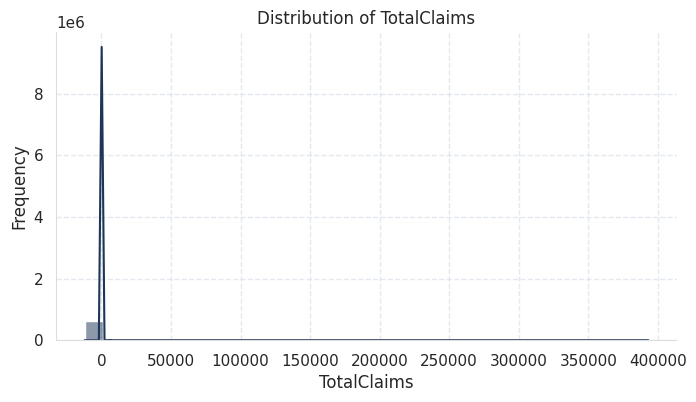

In [ ]:
plot_numericals_frequency(df_clean, numerical_cols)

### Categorical Columns EDA

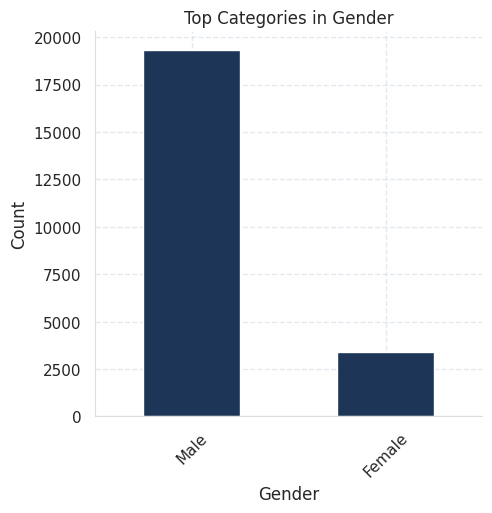

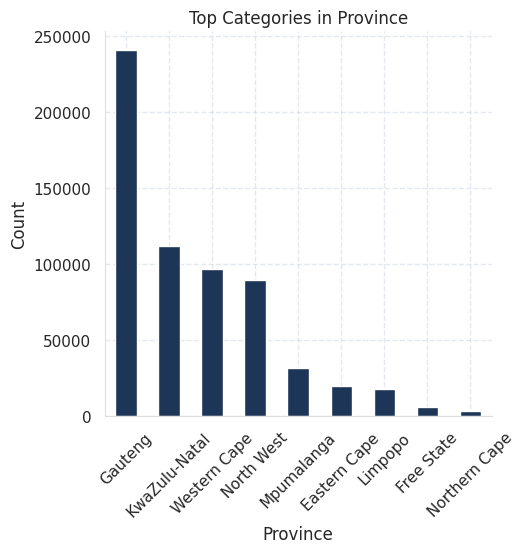

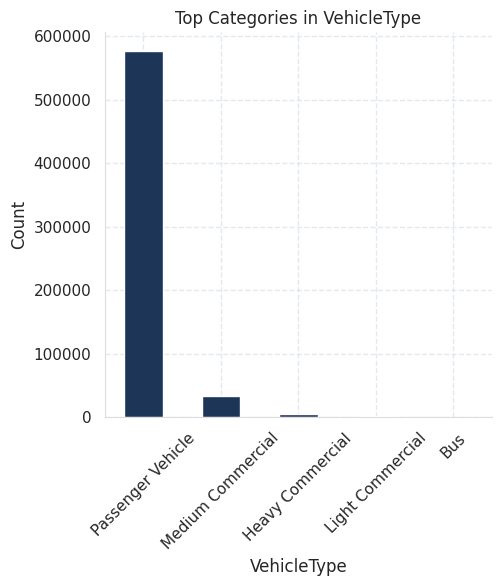

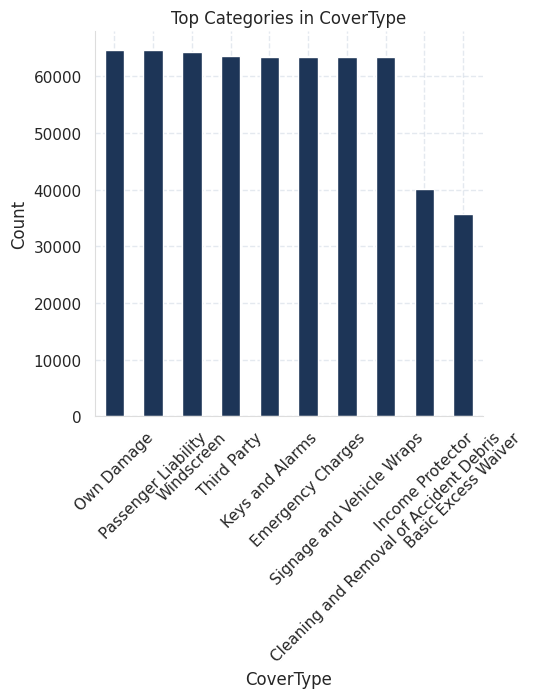

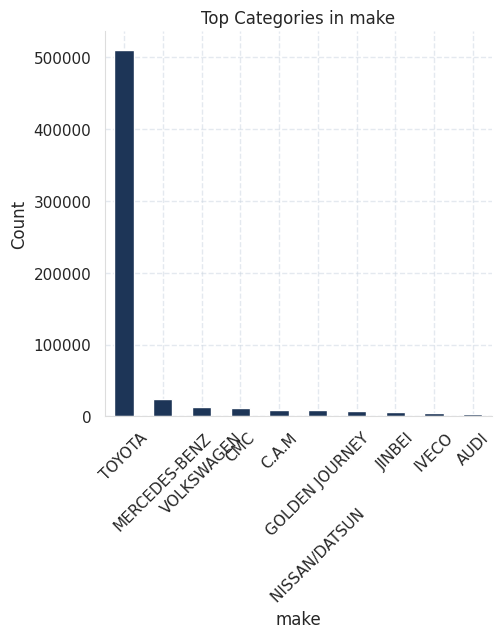

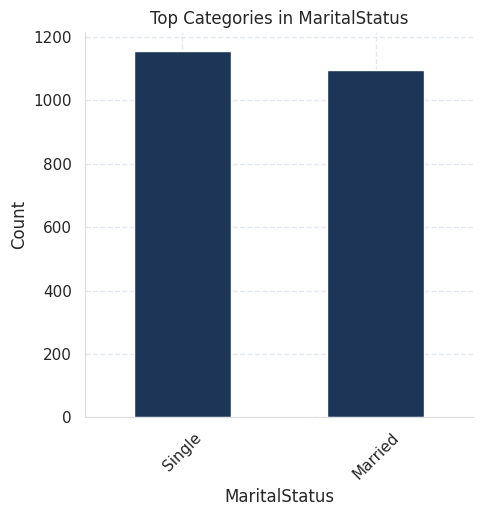

In [ ]:
categorical_cols = ['Gender','Province','VehicleType','CoverType','make','MaritalStatus']

plot_categoricals_count(df_clean, categorical_cols)

## TotalClaim vs Total Premium

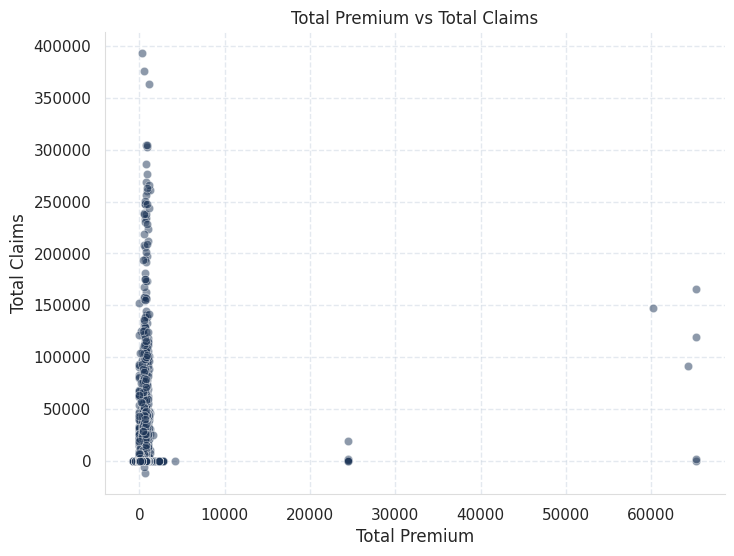

In [ ]:
plot_claim_premium(df_clean)

### Insight

    -   The scatter plot is difficult to interprete as it is zero-inflated 

    Therefore, Log transformation will be applied to.
    


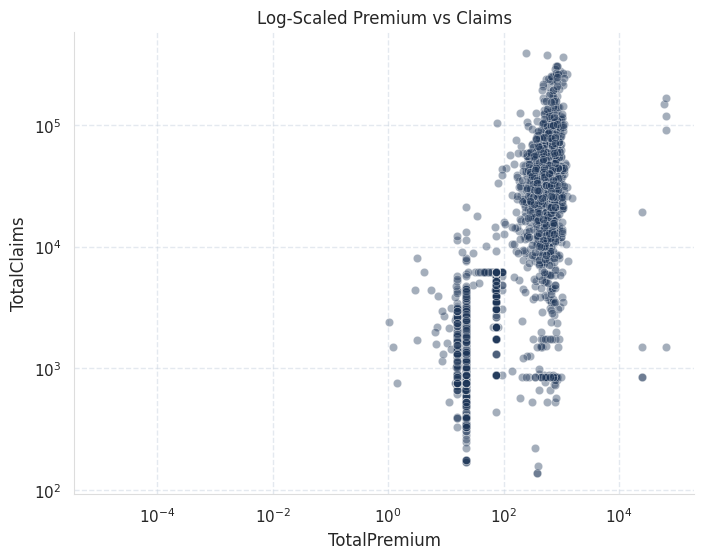

<Figure size 1000x600 with 0 Axes>

In [ ]:
plot_log_claim_premium(df_clean)

### Insight:
    -   Premiums are sold as a flat rate without considering their claim price.

    -   

## Which group Claims the most?

We are conducting analysis for:

    - Claim Frequency - Claim Rate - which tell us the probability of a policy holder in a given group will file a claim.

    - Average Premium - Average of paid premium paid per given group

    - Claim Severity - Average claim Amount - The average claimed amount per group

    - Total Policy holder - Amount of policy holder in given group



#### Claims per Gender

In [ ]:
# Create a mask for policyholders who actually have claims
has_claims = df_clean['TotalClaims'] > 0

gender_diag = df_clean.groupby('Gender').agg(
    #The proportion of policies that made at least one claim.
    Claim_Rate=('TotalClaims', lambda x: x.mean() * 100),
    Average_Premium=('TotalPremium', 'mean'),
    #  Claim Severity: Average claim amount
    Average_Claim_Amount=('TotalClaims', lambda x: x[has_claims.loc[x.index]].mean()),

    Total_Policyholders=('PolicyID', 'count')
).reset_index()

print("=== Demographic Risk Diagnostics by Gender ===")
print(gender_diag)


=== Demographic Risk Diagnostics by Gender ===
   Gender   Claim_Rate  Average_Premium  Average_Claim_Amount  \
0  Female  7349.371461        89.421601          17874.721303   
1    Male  7224.455158        81.732933          14858.552294   

   Total_Policyholders  
0                 3405  
1                19333  


In [ ]:
print(gender_diag.columns)

Index(['Gender', 'Claim_Rate', 'Average_Premium', 'Average_Claim_Amount',
       'Total_Policyholders'],
      dtype='str')


In [ ]:
gender_diag = gender_diag.reset_index()

## Gender Diagnostics

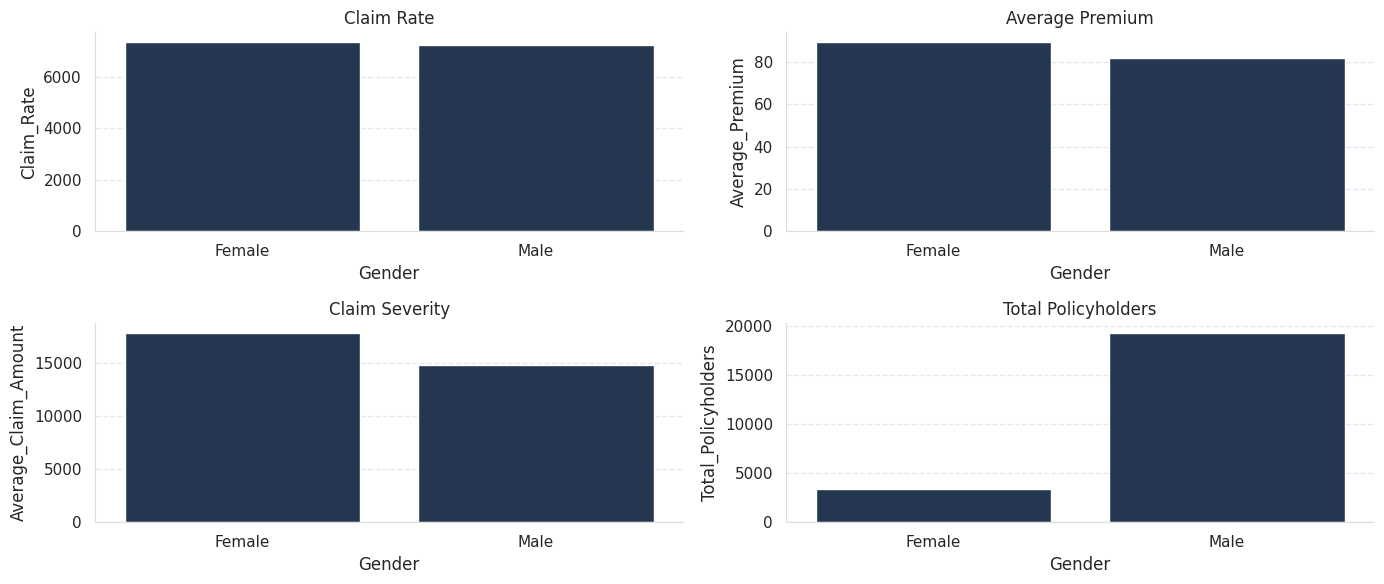

In [ ]:
plot_diagnostics(gender_diag, 'Gender')

### Insight:

    -   Eventhough there is high amount of male policy holders, women has a high claim frequency and severity with a higher average premium payment.

## claim Frequency 


#### Claims per Martial status

In [ ]:
# Create a mask for policyholders who actually have claims
has_claims = df_clean['TotalClaims'] > 0

martial_diag = df_clean.groupby('MaritalStatus').agg(
    
    #The proportion of policies that made at least one claim.
    Claim_Rate=('TotalClaims', lambda x: x.mean() * 100),
    Average_Premium=('TotalPremium', 'mean'),
    # Use a lambda that safely filters the targeted series using the external boolean mask
    Average_Claim_Amount=('TotalClaims', lambda x: x[has_claims.loc[x.index]].mean()),
    Total_Policyholders=('PolicyID', 'count')
).reset_index()

print("=== Demographic Risk Diagnostics by MaritalStatus ===")
print(martial_diag)

=== Demographic Risk Diagnostics by MaritalStatus ===
  MaritalStatus    Claim_Rate  Average_Premium  Average_Claim_Amount  \
0       Married  10192.262454        97.469452          18617.866082   
1        Single   7418.821362       104.710601          21458.940789   

   Total_Policyholders  
0                 1096  
1                 1157  


In [ ]:
martial_diag = martial_diag.reset_index()

## Martial Status Diagnostics

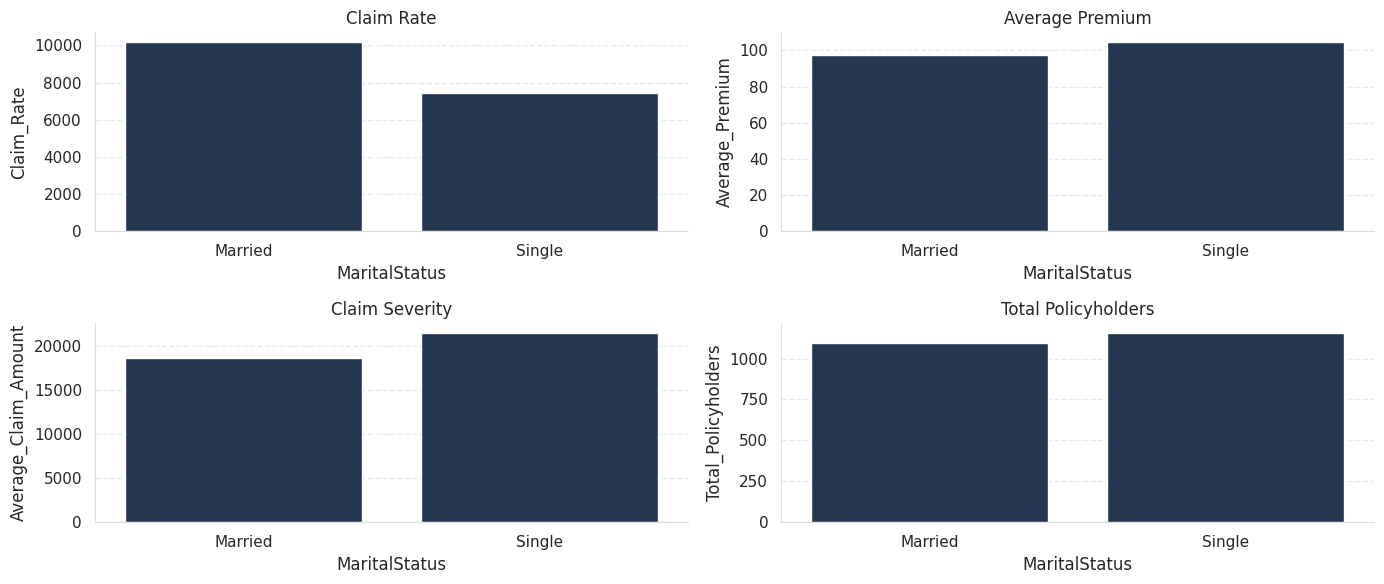

In [ ]:
plot_diagnostics(martial_diag, 'MaritalStatus')

### Insight

    -   The sigle clients have higher policy holder and high premium payer. Eventhough they have a higher average claim, the marrieds are the one who is claiming more frequently.

#### Claims per Province

In [ ]:
# Create a mask for policyholders who actually have claims
has_claims = df_clean['TotalClaims'] > 0

province_diag = df_clean.groupby('Province').agg(
    
    #The proportion of policies that made at least one claim.
    Claim_Rate=('TotalClaims', lambda x: x.mean() * 100),
    Average_Premium=('TotalPremium', 'mean'),
    # Use a lambda that safely filters the targeted series using the external boolean mask
    Average_Claim_Amount=('TotalClaims', lambda x: x[has_claims.loc[x.index]].mean()),
    Total_Policyholders=('PolicyID', 'count')
).reset_index()

print("=== Demographic Risk Diagnostics by Province ===")
print(province_diag)

=== Demographic Risk Diagnostics by Province ===
        Province    Claim_Rate  Average_Premium  Average_Claim_Amount  \
0   Eastern Cape   6885.065042       108.629198          27128.533277   
1     Free State   5981.164003        87.860338          32265.661085   
2        Gauteng  12202.666223        99.856671          22243.878396   
3  KwaZulu-Natal  12749.511865       117.757371          29609.487473   
4        Limpopo   5643.957304        85.359495          15171.294187   
5     Mpumalanga   6456.597695        89.563343          15979.553421   
6     North West   6591.678352        83.400229          16963.467035   
7  Northern Cape   2456.505868        86.894887          11186.313596   
8   Western Cape  10734.457156       101.318936          28095.849881   

   Total_Policyholders  
0                19701  
1                 5934  
2               240883  
3               112172  
4                18010  
5                31668  
6                89814  
7                 36

In [ ]:
province_diag = province_diag.reset_index()

## Province Diagnostics

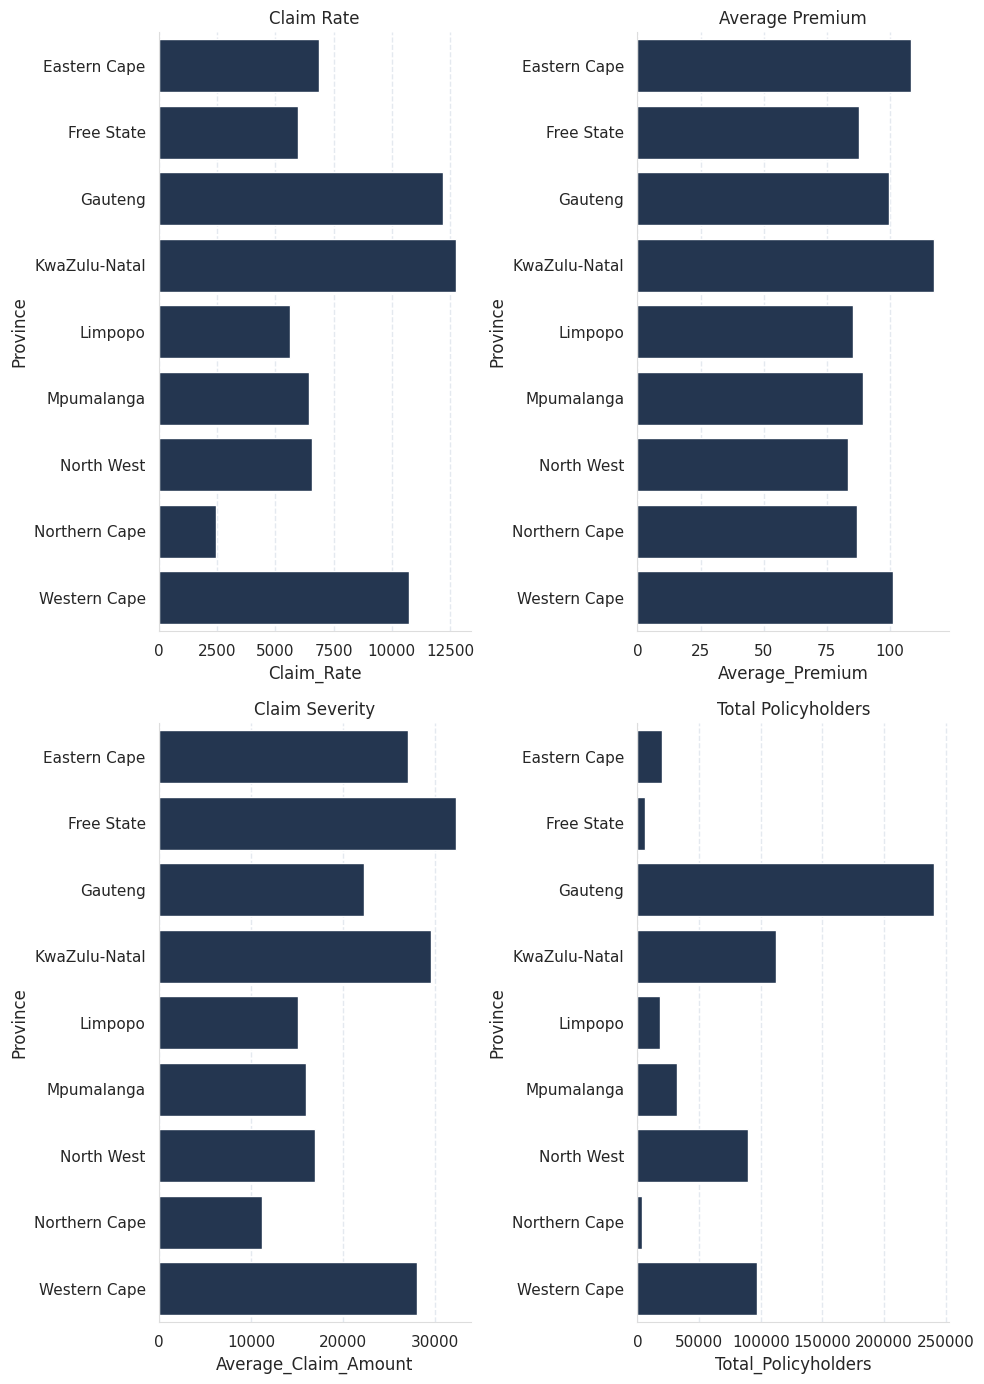

In [ ]:
plot_diagnostics_row(province_diag, 'Province')

Insight:

    -   There is a high subscriber/ policy holder in Gauteng province

    -   However the high premium payers are in KwaZulu-Natal, Eastern cape and western cape.

    -   Eventhough, KwaZulu-Natal, Gauteng and western cape has a high frequency in claim requesting.

    -    highest claim average happened to be clients who lives in in Free state

## Loss Ratio by Province

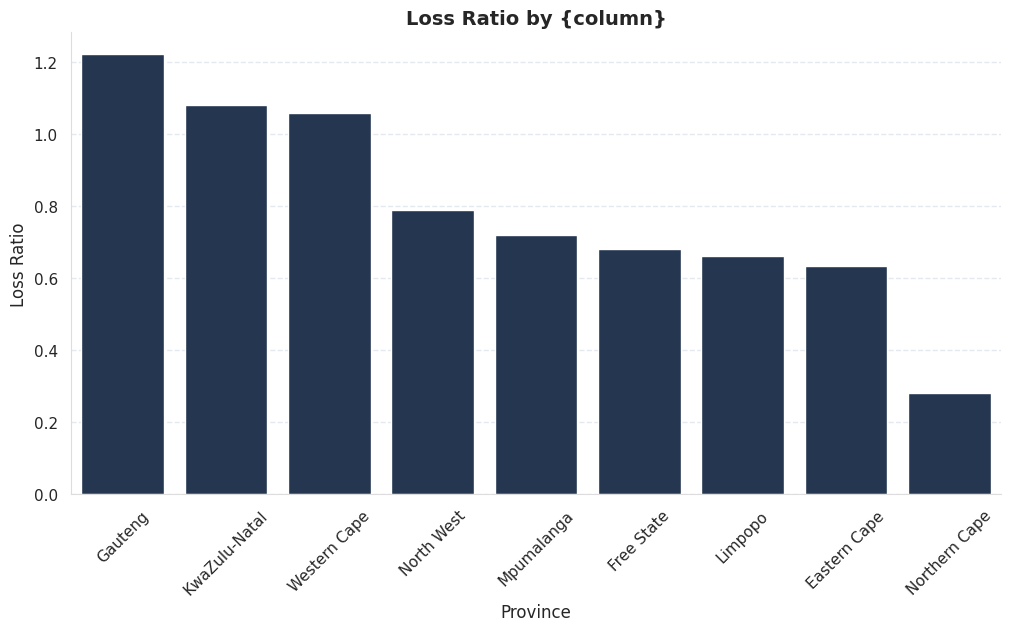

In [ ]:
province_loss = df_clean.groupby('Province').agg({'TotalClaims': 'sum','TotalPremium': 'sum'})

province_loss['LossRatio'] = (province_loss['TotalClaims'] /province_loss['TotalPremium'])

province_loss = (province_loss.sort_values('LossRatio', ascending=False).reset_index())

plot_lossRatio(province_loss, 'Province')

### Insight:

    -   Guateng Kwazulu_natal and Wester Cape are having extreme higher loss ratios
    
    -   this suggest that there is a higher insurance risk exposure in these areas or possible underpricing of premium.

#### Claims per Vehicle Type

In [ ]:
# Create a mask for policyholders who actually have claims
has_claims = df_clean['TotalClaims'] > 0

vtype_diag = df_clean.groupby('VehicleType').agg(
    
    #The proportion of policies that made at least one claim.
    Claim_Rate=('TotalClaims', lambda x: x.mean() * 100),
    Average_Premium=('TotalPremium', 'mean'),
    # Use a lambda that safely filters the targeted series using the external boolean mask
    Average_Claim_Amount=('TotalClaims', lambda x: x[has_claims.loc[x.index]].mean()),
    Total_Policyholders=('PolicyID', 'count')
).reset_index()

print("=== Demographic Risk Diagnostics by VehicleType ===")
print(vtype_diag)

=== Demographic Risk Diagnostics by VehicleType ===
         VehicleType    Claim_Rate  Average_Premium  Average_Claim_Amount  \
0                Bus   1773.067647       129.145764           7996.535088   
1   Heavy Commercial  17591.996796       108.051538          35736.884921   
2   Light Commercial   2312.643458        99.654752           7556.562500   
3  Medium Commercial  12321.281519       117.317509          26075.106972   
4  Passenger Vehicle  10278.635255        98.060019          22957.374038   

   Total_Policyholders  
0                  451  
1                 4266  
2                 2614  
3                33437  
4               577626  


In [ ]:
# forcing the index back into a regular column
vtype_diag = vtype_diag.reset_index()

## Vehicle Type Diagnostics

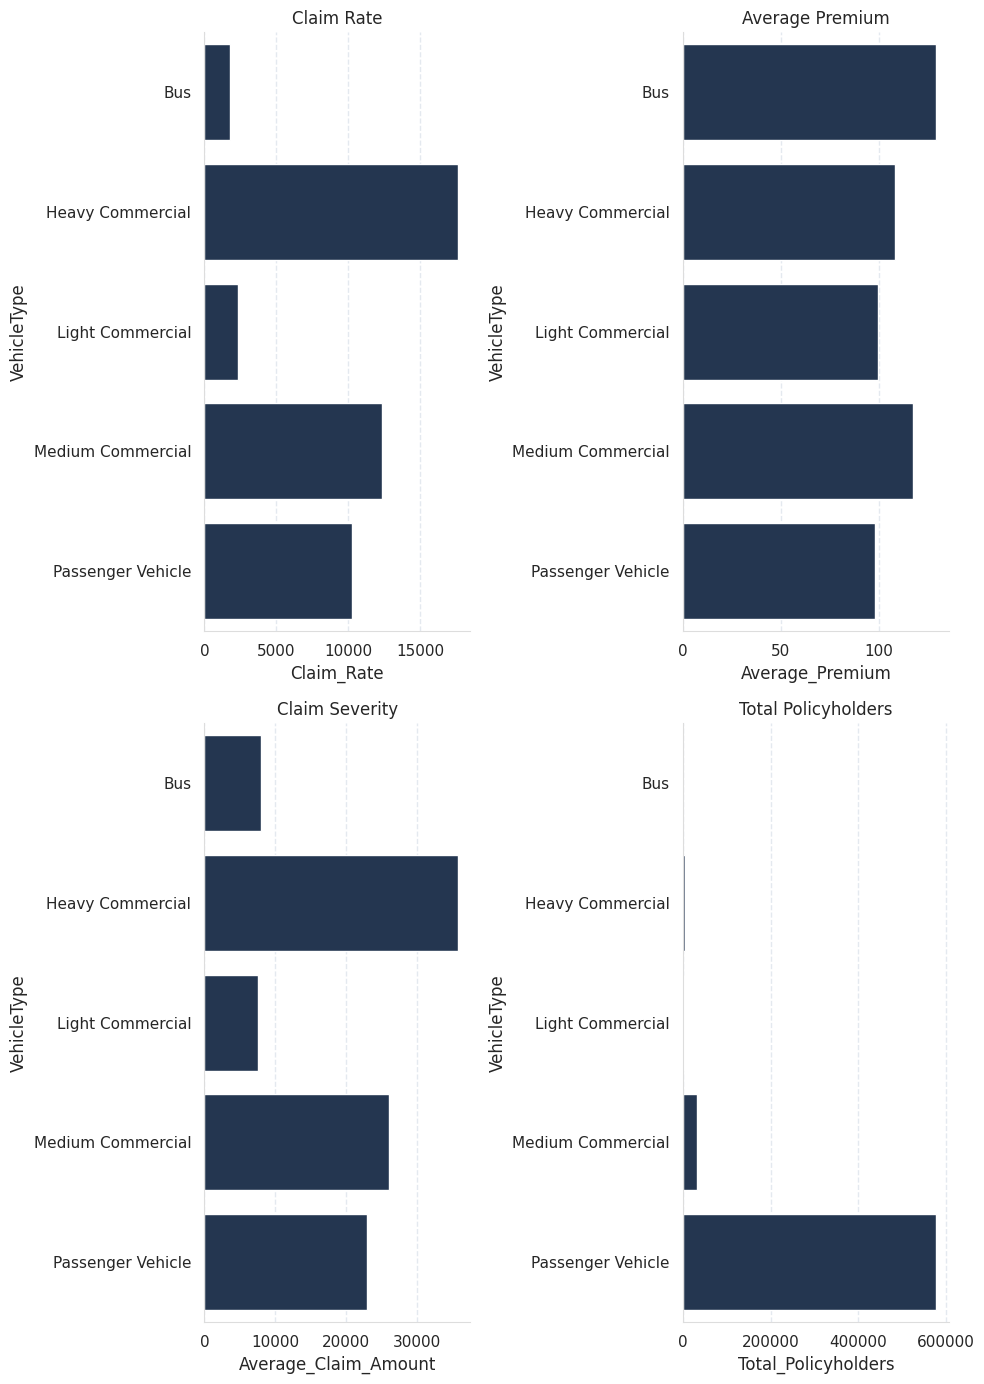

In [ ]:
plot_diagnostics_row(vtype_diag, 'VehicleType')

### Insight:

    -   The highest subscriber of the company are clients who have a passenger vehicle. However Buses and Medium Commercial owners are the highest premium payers.

    -   Heavy commercial vehicle owners are the most frequent claim requesters whith highest average claim amount.

#### Claims per Model

In [ ]:
# Create a mask for policyholders who actually have claims
has_claims = df_clean['TotalClaims'] > 0

vmodel_diag = df_clean.groupby('Model').agg(
    
    #The proportion of policies that made at least one claim.
    Claim_Rate=('TotalClaims', lambda x: x.mean() * 100),
    Average_Premium=('TotalPremium', 'mean'),
    # Use a lambda that safely filters the targeted series using the external boolean mask
    Average_Claim_Amount=('TotalClaims', lambda x: x[has_claims.loc[x.index]].mean()),
    Total_Policyholders=('PolicyID', 'count')
).reset_index()

print("=== Demographic Risk Diagnostics by MOdel ===")
print(vmodel_diag)

=== Demographic Risk Diagnostics by MOdel ===
                                 Model  Claim_Rate  Average_Premium  \
0                   0305 M BAR B/S CCL         0.0       131.563017   
1    115 VITO 2.2 CDI CREW CAB F/C P/V         0.0        43.859649   
2                       13-206 F/C C/C         0.0        75.115304   
3             1400 CHAMP (B01) P/U S/C         0.0        69.782570   
4                        3 1.6 DYNAMIC         0.0       112.590168   
..                                 ...         ...              ...   
387                       YARIS T3 A/C         0.0        43.859649   
388                YARIS T3 SPIRIT 5Dr         0.0        65.589383   
389                          YARIS T3+         0.0        44.951033   
390                         YARIS ZEN3         0.0        80.748596   
391                     YARIS ZEN3 ACS         0.0        80.679671   

     Average_Claim_Amount  Total_Policyholders  
0                     NaN                   54  
1  

In [ ]:
vmodel_diag = vmodel_diag.reset_index()

## Vehicle Model Diagnostics

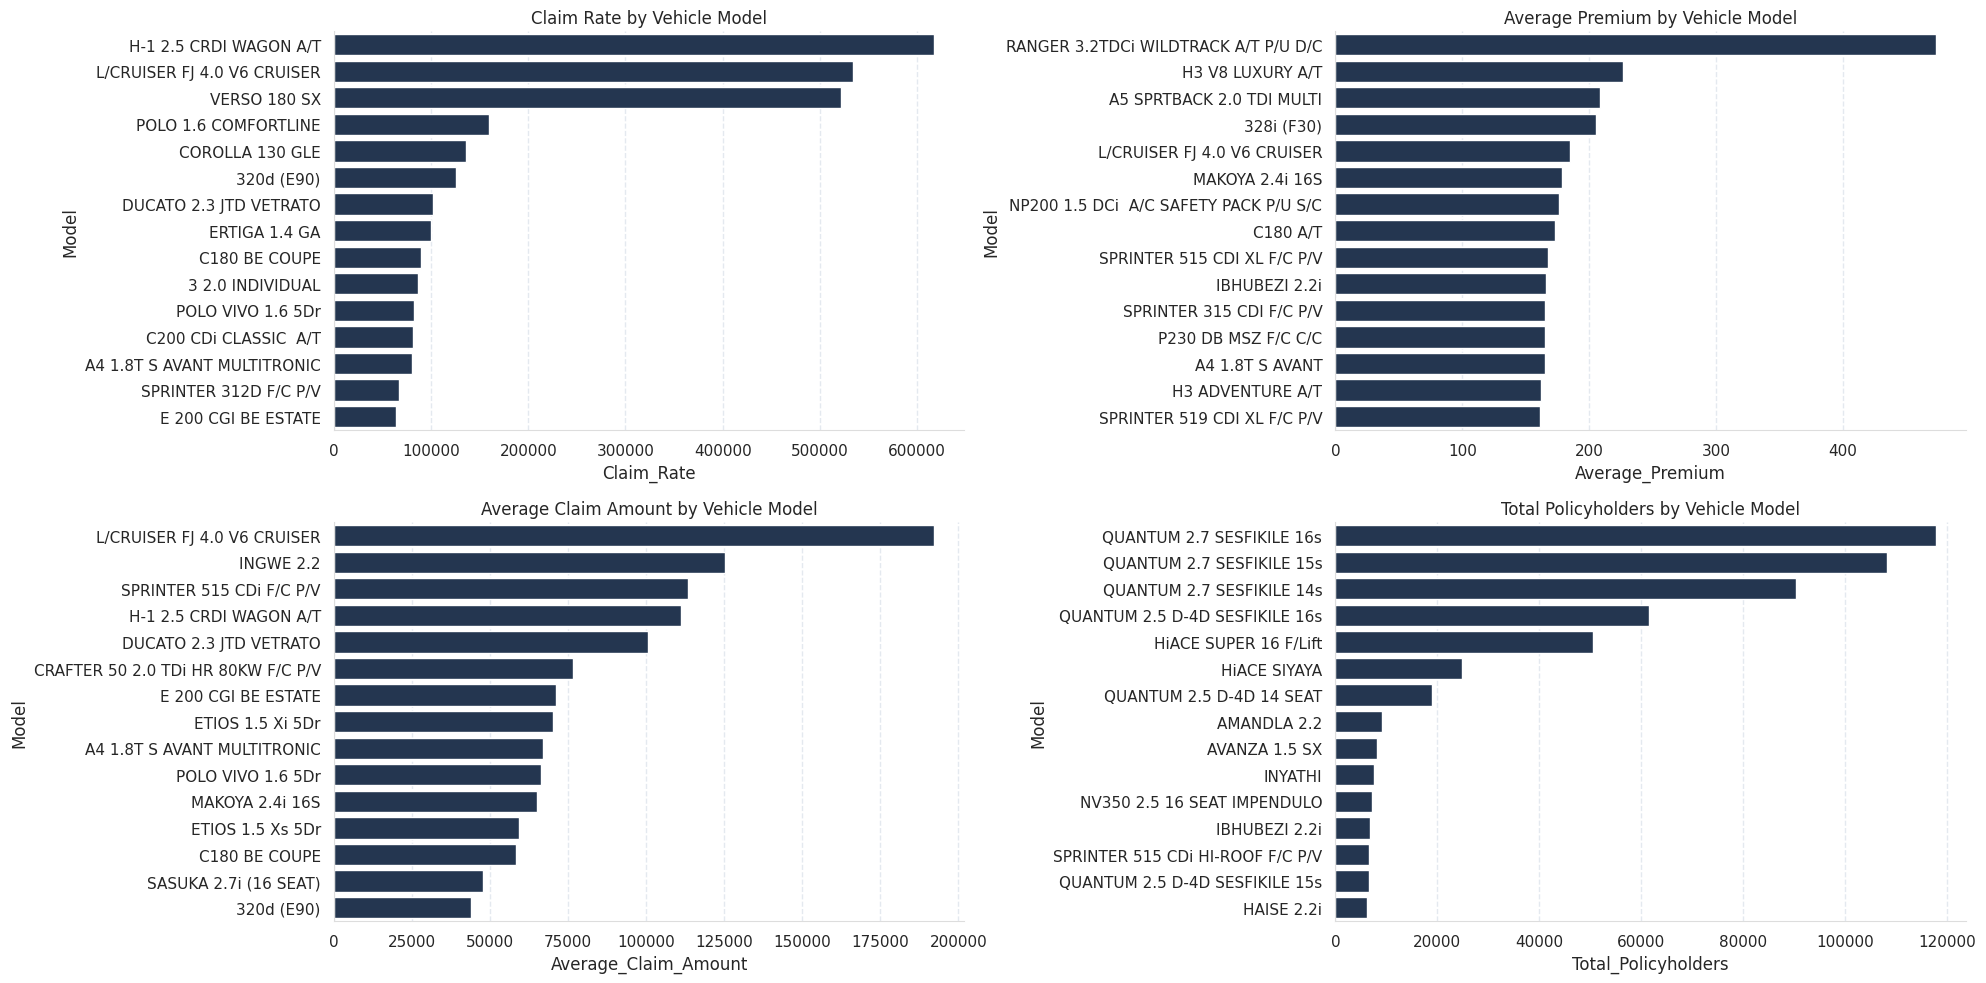

In [ ]:
plot_diagnostics_vehicleModel(vmodel_diag)

## Insight:

    -   Quantum car are more Insured than others.

    -   Ranger car owners pay the highest average premium.

    -   Cardi Wagon vehicles are more prone to accident as they have the highest claim frequency

    -   Land Cruiser might have a high maintenace cost as they have a the highest average claim amount.


#### Claims per make

In [ ]:
# Create a mask for policyholders who actually have claims
df_clean['make'] = df_clean['make'].astype(str).str.strip().str.upper()
has_claims = df_clean['TotalClaims'] > 0

vmake_diag = df_clean.groupby('make').agg(
    
    #The proportion of policies that made at least one claim.
    Claim_Rate=('TotalClaims', lambda x: x.mean() * 100),
    Average_Premium=('TotalPremium', 'mean'),
    # Use a lambda that safely filters the targeted series using the external boolean mask
    Average_Claim_Amount=('TotalClaims', lambda x: x[has_claims.loc[x.index]].mean()),
    Total_Policyholders=('PolicyID', 'count')
).reset_index()

print("=== Demographic Risk Diagnostics by Make ===")
print(vmake_diag)

=== Demographic Risk Diagnostics by Make ===
              make    Claim_Rate  Average_Premium  Average_Claim_Amount  \
0             AUDI  27328.793165       100.715824          30939.506443   
1            B.A.W  20612.883969       119.198862          47856.245614   
2              BMW  19620.910772        98.926342          19259.886014   
3            C.A.M   7311.699282        63.853192          25769.636543   
4            CHERY      0.000000       106.912044                   NaN   
5        CHEVROLET   1877.277097        68.448806           8222.473684   
6          CITROEN      0.000000       103.552429                   NaN   
7              CMC  11471.793482        82.981973          30082.171180   
8         DAIHATSU      0.000000        43.859649                   NaN   
9             FIAT  11942.752132       116.890254          26721.907895   
10            FORD    576.404996        84.525598           2040.473684   
11           FOTON    654.486162        77.450268      

In [ ]:
vmake_diag = vmake_diag.reset_index()

## Vehicle Make Diagnostics

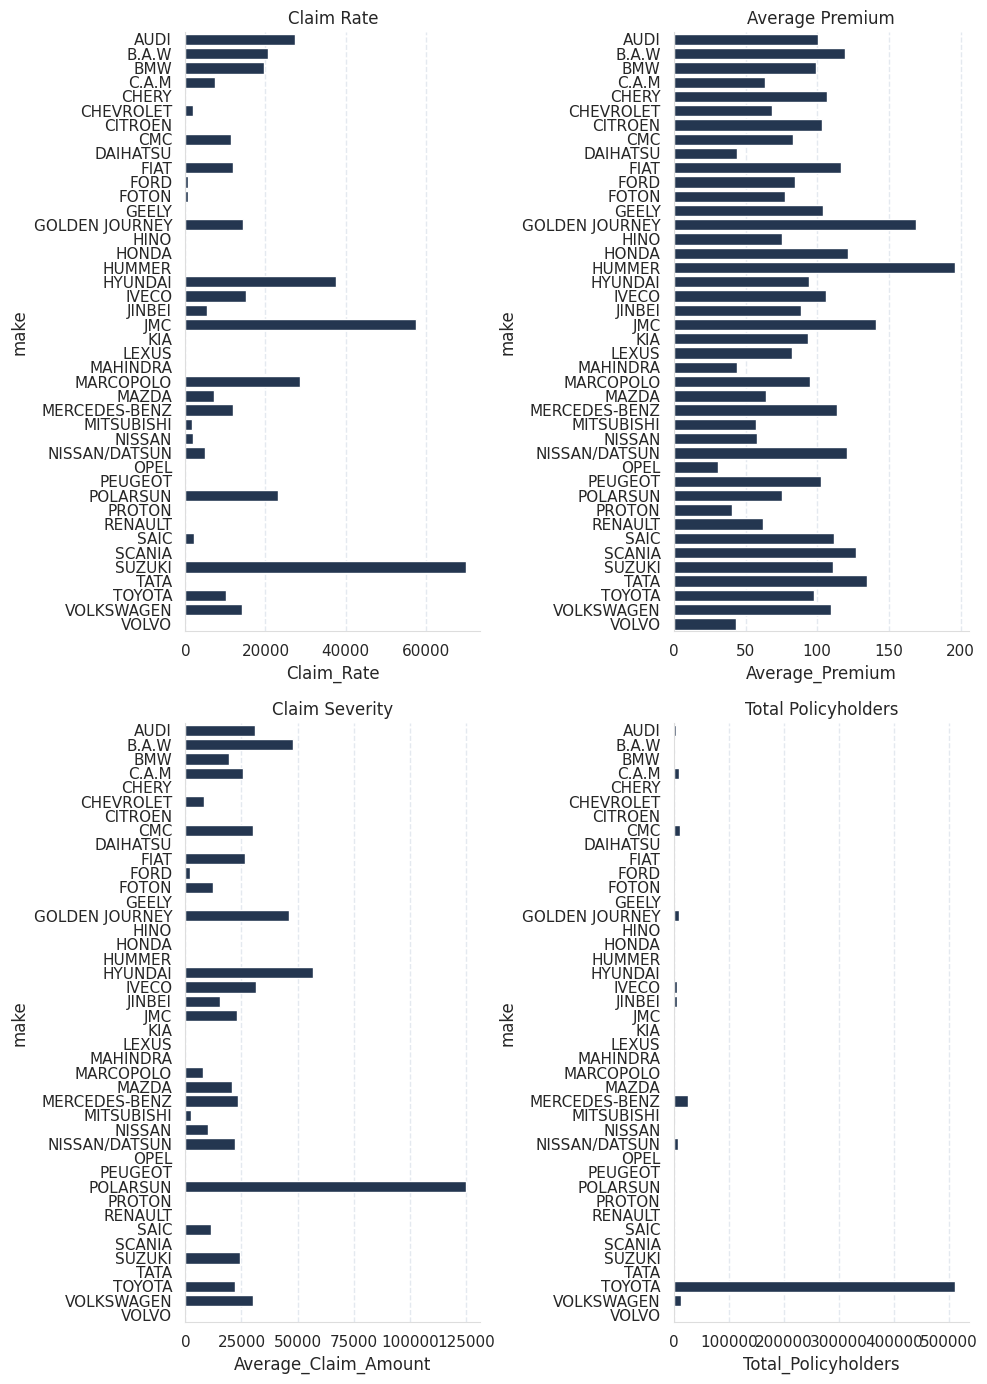

In [ ]:
plot_diagnostics_row(vmake_diag, 'make')

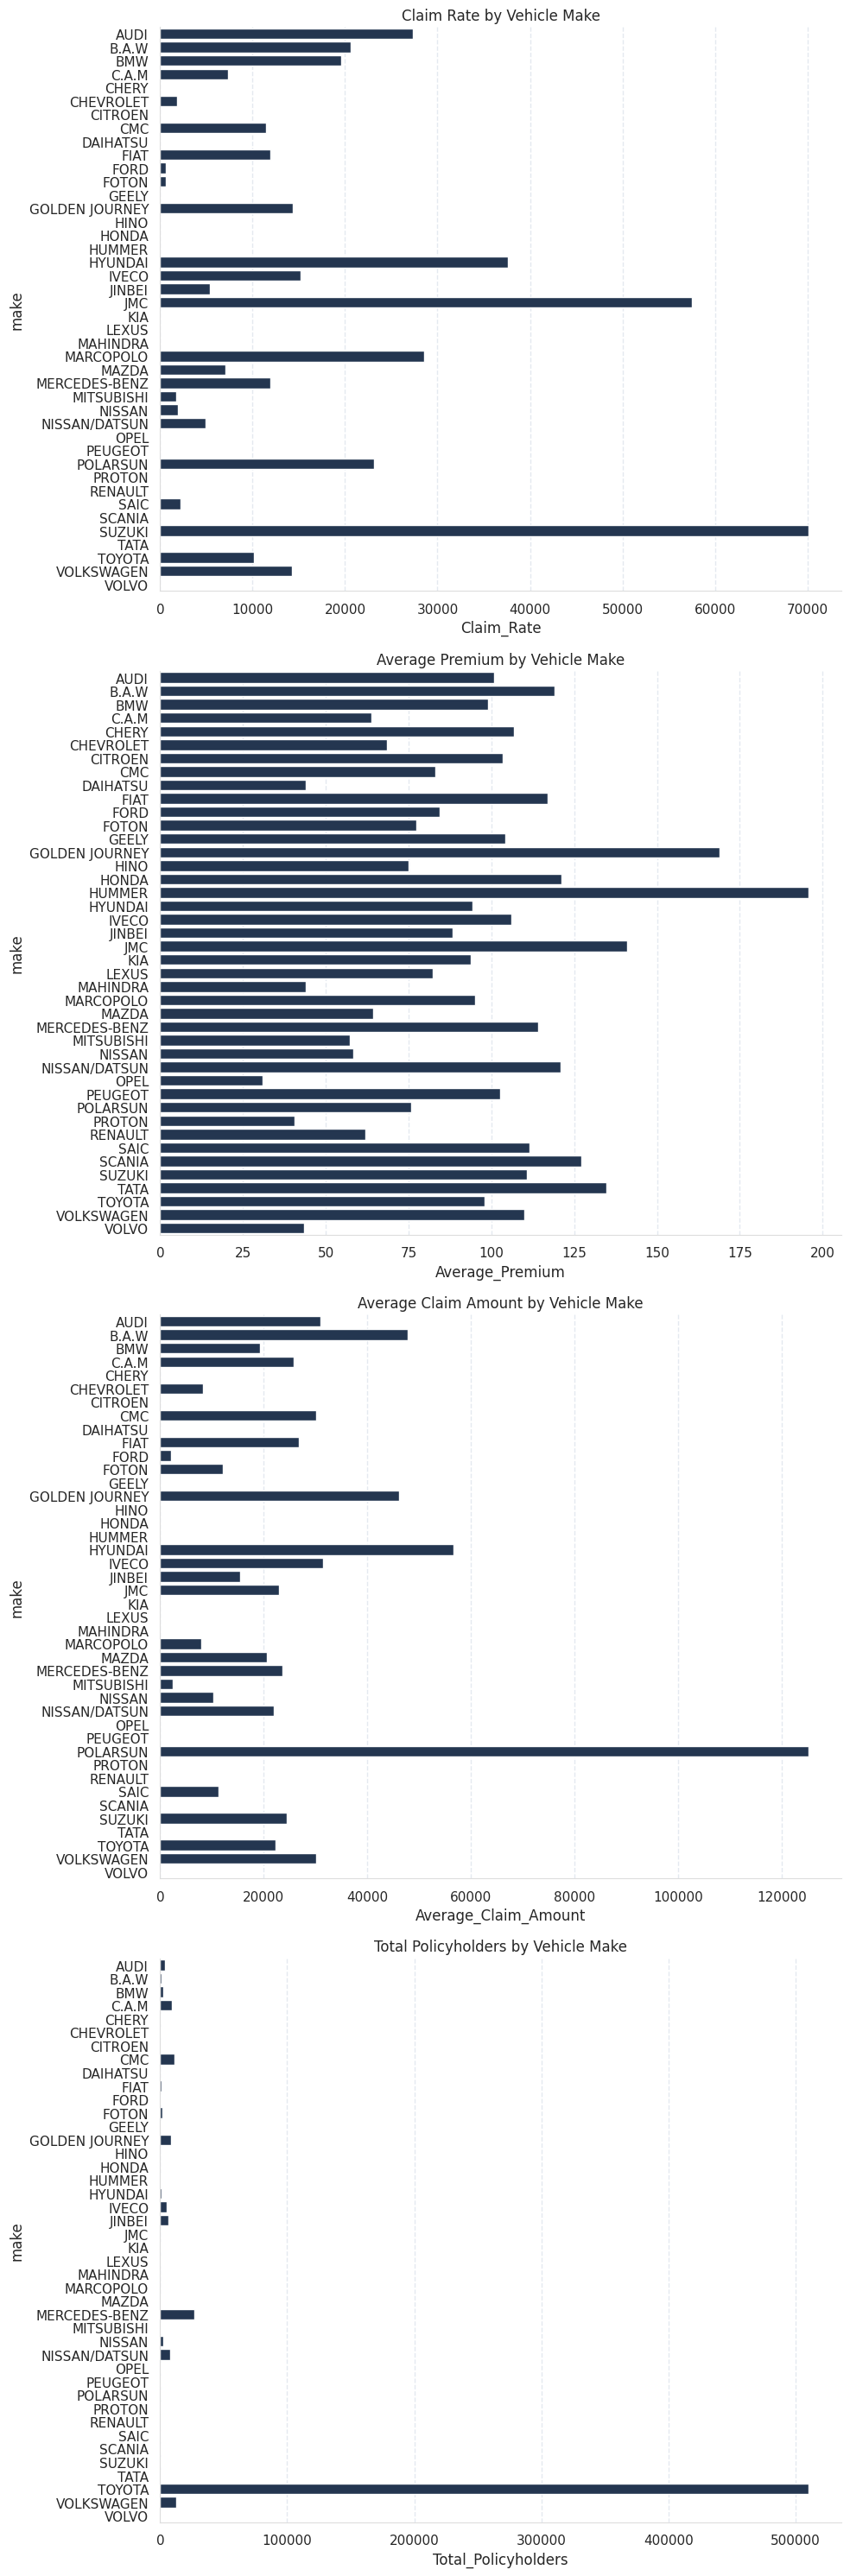

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(10, 30))

# Claim Rate
sns.barplot(data=vmake_diag,y='make',x='Claim_Rate', ax=axes[0])
axes[0].set_title('Claim Rate by Vehicle Make')

# Average Premium
sns.barplot(data=vmake_diag,y='make',x='Average_Premium', ax=axes[1])
axes[1].set_title('Average Premium by Vehicle Make')

# Average Claim Amount
sns.barplot(data=vmake_diag,y='make',x='Average_Claim_Amount', ax=axes[2])
axes[2].set_title('Average Claim Amount by Vehicle Make')

# Total Policyholders
sns.barplot(data=vmake_diag,y='make',x='Total_Policyholders', ax=axes[3])
axes[3].set_title('Total Policyholders by Vehicle Make')

plt.tight_layout()
plt.show()

### Insight:

    -   Toyota vehicle owners are the higheat policy holder in the company

    -   The vehicles that has a higher premium average are Golden Journey and Hammer.

    -   Eventhough Suzuki and JMC are the most frequent claim requester, POlarsun is the highest claim costly Vehicle.

### Claim per Vehicle Age

In [ ]:
# 2. Get today's date and calculate vehicle age in YEARS (rounded)
todays_date = pd.Timestamp.now()
df_clean['Vehicle_Age_Years'] = ((todays_date - df_clean['VehicleIntroDate']).dt.days / 365.25).round(0)

#sparse vehicle ages into clean categories
bins = [0, 15, 20, 25, 30, np.inf]
labels = ["0-15 Years", "16-20 Years", "21-25 Years", "26-30 Years", "31+ Years"]

df_clean['VehicleAgeGroup'] = pd.cut(df_clean['Vehicle_Age_Years'], bins=bins, labels=labels)

# Create the mask for policyholders who actually have claims
has_claims = df_clean['TotalClaims'] > 0

# 3. Group by the new 'Vehicle_Age_Years' column
vage_diag = df_clean.groupby('VehicleAgeGroup').agg(
    
    #The proportion of policies that made at least one claim.
    # % with a claim
    Claim_Rate=('TotalClaims', lambda x: (x > 0).mean() * 100), # % of policies with a claim
    Average_Premium=('TotalPremium', 'mean'),
    # Safely filter claims > 0 for the average claim size calculation
    Average_Claim_Amount=('TotalClaims', lambda x: x[x > 0].mean()),
    Total_Policyholders=('PolicyID', 'count')
).reset_index()

print("=== Demographic Risk Diagnostics by Vehicle Age ===")
print(vage_diag)

=== Demographic Risk Diagnostics by Vehicle Age ===
  VehicleAgeGroup  Claim_Rate  Average_Premium  Average_Claim_Amount  \
0      0-15 Years    0.441872       118.494658          27450.002251   
1     16-20 Years    0.487345        94.869950          21416.783248   
2     21-25 Years    0.375750        83.894233          20267.123973   
3     26-30 Years    0.791640        63.221451          12996.029123   
4       31+ Years    0.337070        62.071591          18799.214157   

   Total_Policyholders  
0               219068  
1               280910  
2                63340  
3                 3158  
4                51918  


In [ ]:
vage_diag = vage_diag.reset_index()

## Vehicle Age Diagnostics


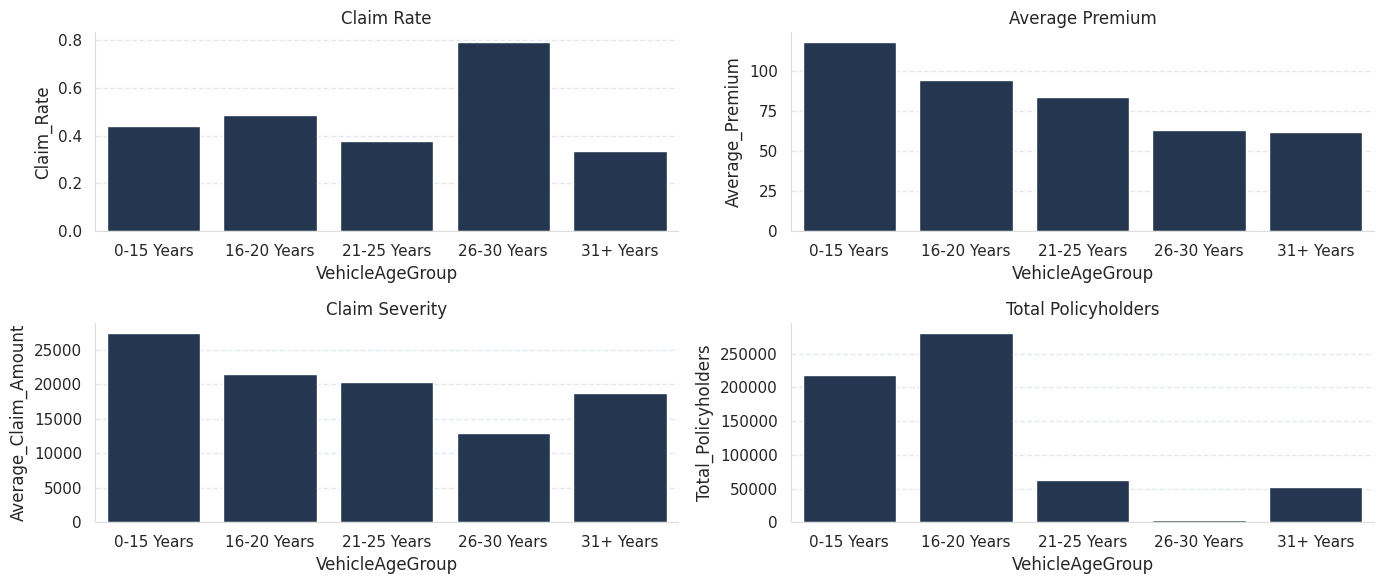

In [ ]:
plot_diagnostics(vage_diag, 'VehicleAgeGroup')

## Insight:

    -   Cars aged in between 16 and 20 are the highest insured cars and new cars age between 0 - 15 are the highest premium payers.

    -   The most frequently claimed cars are vehicles aged with 26 to 30 however they are the least averaged vehicles. This might means that they are easly maintainable.

    -   and the highest claim expend on new cars.

### Distribution of Claim

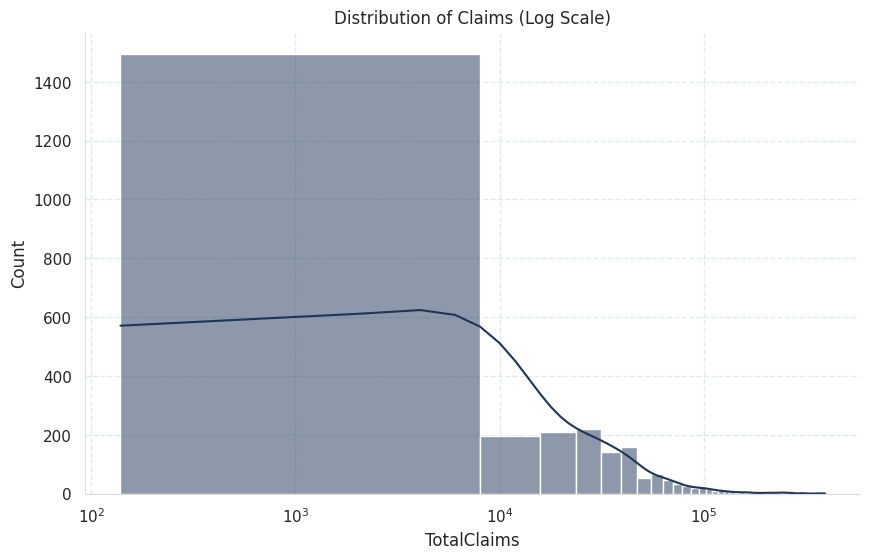

In [ ]:
sns.histplot(
    df[df['TotalClaims'] > 0]['TotalClaims'],
    bins=50,
    kde=True
)

plt.xscale('log')

plt.title('Distribution of Claims (Log Scale)')

plt.show()

### Insight:
    -   Even if The most claim covered costs ranges from 100 - 10000
 
    - Eventhough there is small claim counts that is above 10000, it has significant effect.

### Highest Claims

In [ ]:
high_claims = df_clean[
    df_clean['TotalClaims'] >
    df_clean['TotalClaims'].quantile(0.999)
]

print(high_claims[
    [
        'PolicyID', 
        'VehicleType',
        'make',
        'Province',
        'TotalClaims',
        'TotalPremium'
    ]
].head())

       PolicyID        VehicleType    make       Province   TotalClaims  \
1560       8672  Passenger Vehicle     BMW        Gauteng  46492.211754   
3220        839  Passenger Vehicle  TOYOTA     Mpumalanga  74967.017544   
6662      12071  Passenger Vehicle  TOYOTA  KwaZulu-Natal  72445.035088   
8857      10800  Passenger Vehicle  TOYOTA  KwaZulu-Natal  34940.947368   
10751     13355  Passenger Vehicle  TOYOTA        Gauteng  34949.947368   

       TotalPremium  
1560    1213.889211  
3220     358.358421  
6662     767.871316  
8857     955.972456  
10751    808.295439  


In [ ]:
zipcode_analysis = (
    df_clean.groupby('PostalCode')
    .agg({
        'TotalPremium': 'mean',
        'TotalClaims': 'mean',
        'PolicyID': 'count'
    })
    .reset_index()
)

zipcode_analysis.rename(columns={
    'PolicyID': 'PolicyCount'
}, inplace=True)

print(zipcode_analysis.head())

   PostalCode  TotalPremium  TotalClaims  PolicyCount
0           1     95.801869   107.923980         2850
1           2     93.203261    94.770748          653
2           4    113.947737     0.000000           77
3           5     68.504029   230.420906          360
4           6    101.182864    39.220893          220


### Premim Vs Claim by Zip Code

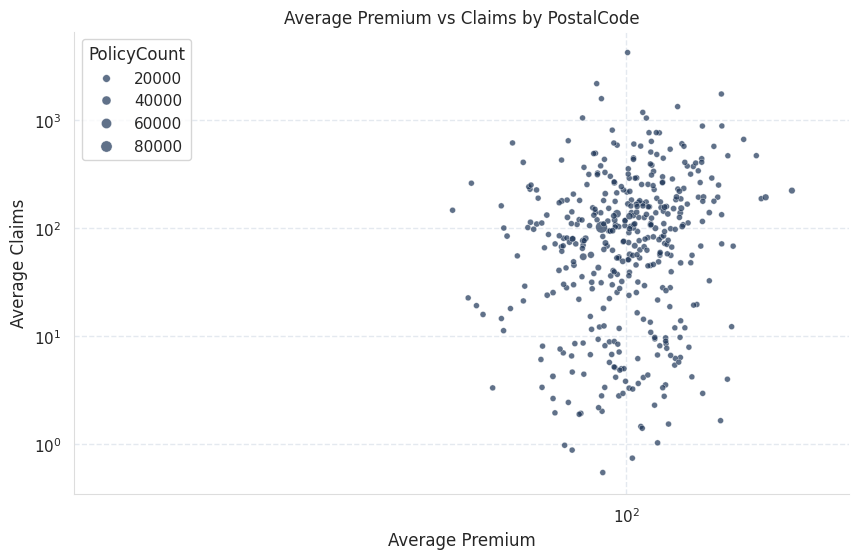

In [ ]:
plot_premium_claim_zipcode(zipcode_analysis)

Insight:
    -   the average policy holders pays premium around 100 for most postal codes. However their claim is avery distinct.

## True Severity by excluding Non_claimers

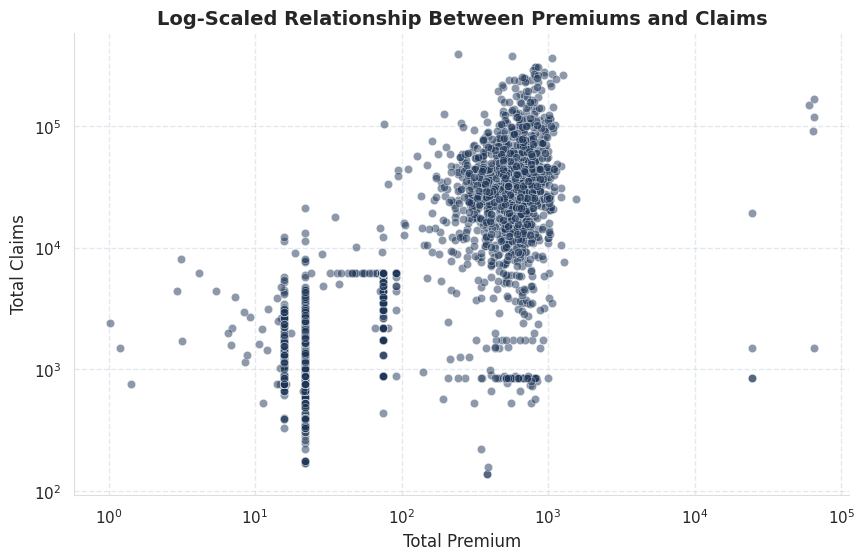

In [ ]:
plot_log_premium_claim_severity(df_clean)

### Insight:

    -   Claims are highly skewed with a heavy-tail distribution therefore log transformation applied.

    -   There are clients with a pays average premium (100 - 1000) but gets a higher severity claim (>10000).
    
    -   The total premium cloud up from the left-bottom. This shows that expensive vehicles demand a high claim. Higher premiums generally correspond to higher claims, though several extreme outliers indicate catastrophic or high-risk policies.

    -   The veritical lined scatteres proves that the company mostly sells insurance with a falt rate. however their claim severity is different.

### Outlier Detection 

In [ ]:
# key Columns identified for further analysis and modeling
key_num_cols = ['TotalPremium', 'TotalClaims','SumInsured','CustomValueEstimate']

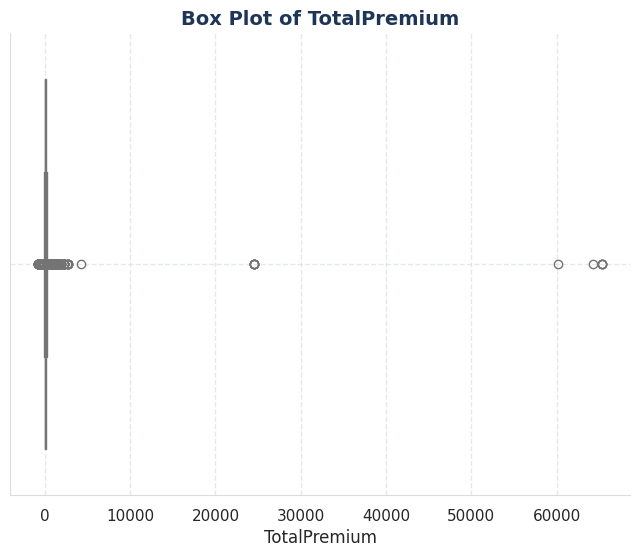

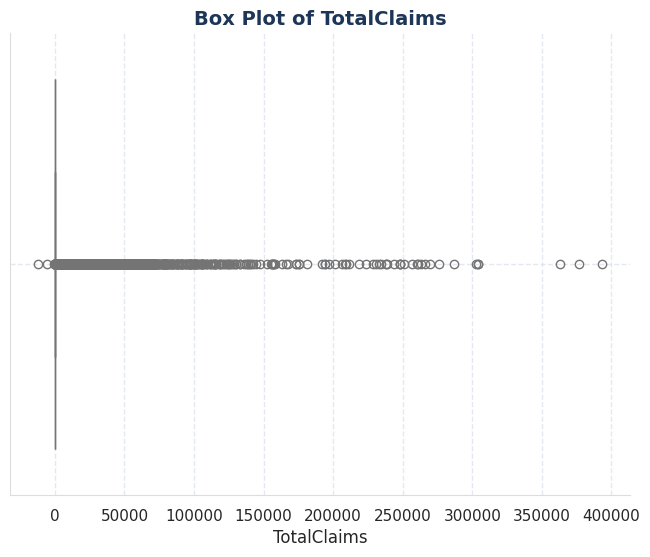

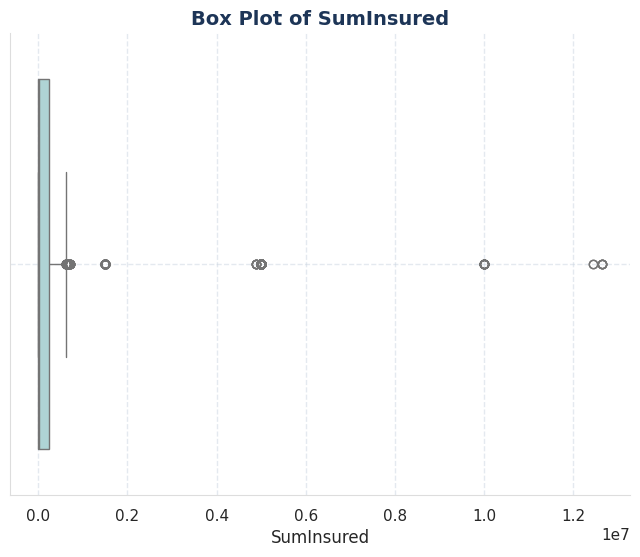

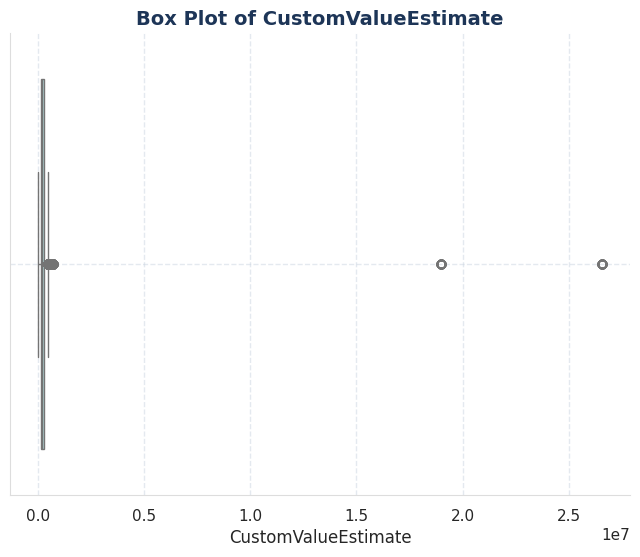

In [ ]:
plot_box_outliers(df_clean, key_num_cols)

### Insight:

    -   The raw boxplots show extreme skew in `TotalPremium` and `TotalClaims`; a small number of very large policies drive the upper tail.

    -   `SumInsured` and `CustomValueEstimate` also exhibit long upper tails, confirming that the portfolio contains heavy-value exposures.

    -   On the raw scale, the outlier signal is masked by magnitude, so log scaling is needed to separate moderate policies from true extreme values.

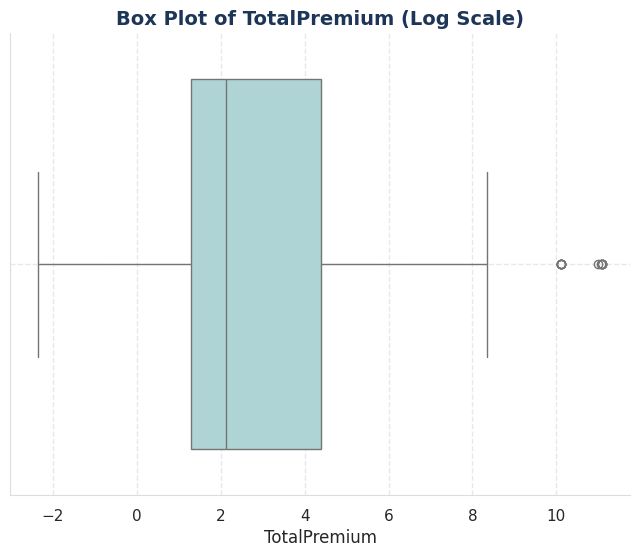

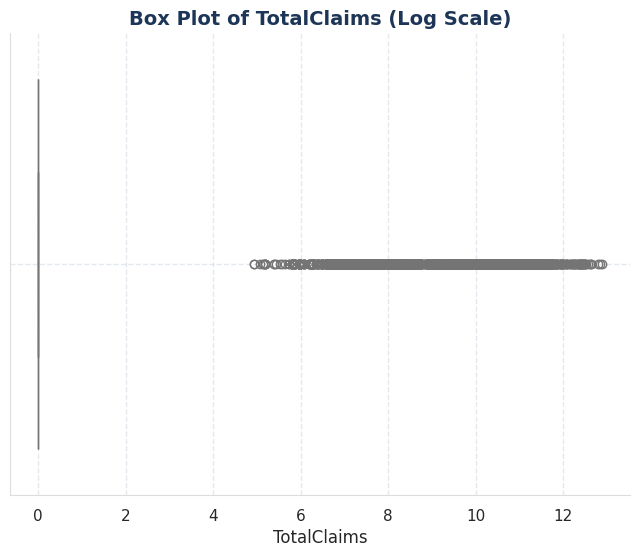

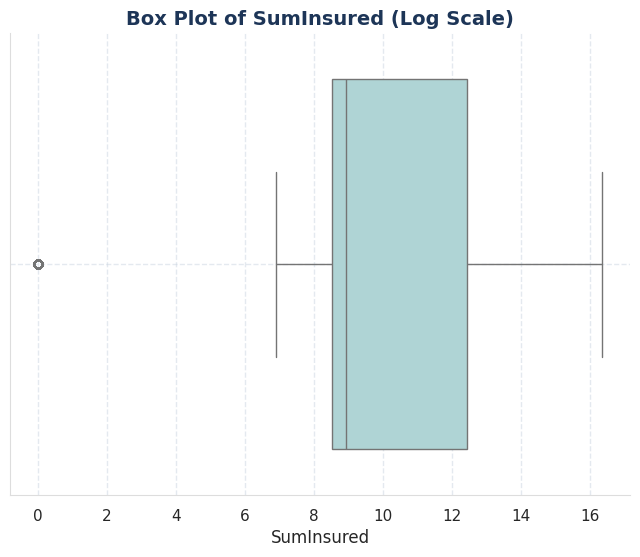

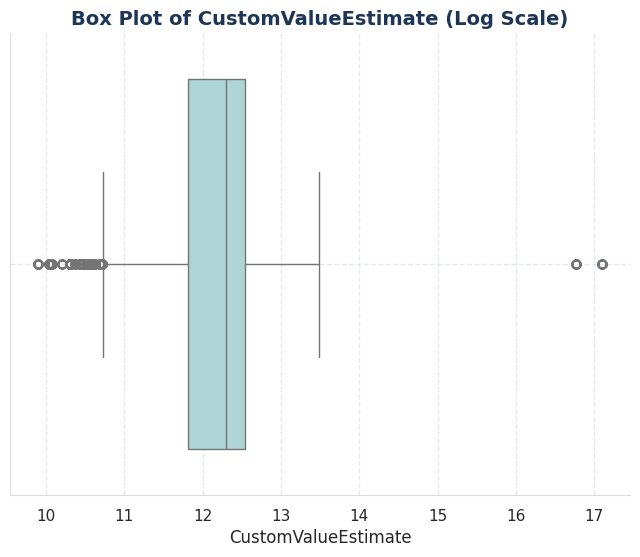

In [ ]:
plot_box_log_outliers(df_clean, key_num_cols)

### Insight:

    -   Log-scaled boxplots compress the heavy tail and make the typical policy range more visible.

    -   Even after log transformation, `TotalClaims` remains long-tailed, showing that a small share of policies continue to dominate claim severity.

    -   This confirms the need for both raw and log-scale views: raw plots show the magnitude of extreme risk, and log plots show the structure of the main policy body.

    -   Percentile-based outlier identification is the next step to isolate the most extreme claim exposures.

## Detect Outliers

In [ ]:
Q1 = df['TotalClaims'].quantile(0.25)
Q3 = df['TotalClaims'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['TotalClaims'] < lower_bound) |
    (df['TotalClaims'] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 2793


### Percentile-Based Outliers

    -   This identifies the top 1% highest claims and isolates the most extreme loss exposures.

    -   The top 1% includes high-severity policies such as BMW and VOLKSWAGEN in Gauteng and KwaZulu-Natal, so these should be prioritized for underwriting review and loss reserving.

    -   IQR-based detection found 2,793 `TotalClaims` outliers, which is consistent with a heavy-tailed claim distribution.

In [ ]:
high_claims = df[
    df['TotalClaims'] >
    df['TotalClaims'].quantile(0.99)
]

print(high_claims[
    [
        'PolicyID',
        'VehicleType',
        'Province',
        'make',
        'TotalClaims'
    ]
].head())

      PolicyID        VehicleType       Province        make   TotalClaims
203       4044  Passenger Vehicle        Gauteng        AUDI   2294.096491
284       7174  Passenger Vehicle        Gauteng        FORD   2040.473684
1560      8672  Passenger Vehicle        Gauteng         BMW  46492.211754
1779       283  Medium Commercial  KwaZulu-Natal  VOLKSWAGEN  26516.859649
1943      8672  Passenger Vehicle        Gauteng         BMW   6140.350877


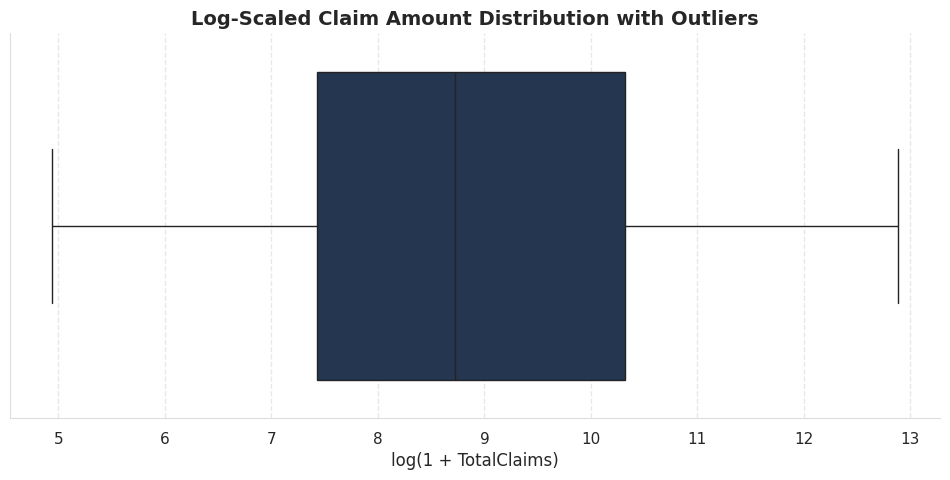

In [ ]:
plot_box_percentile_outliers(df_clean)



## Final Report Summary

### Key Findings
- Portfolio performance is weak: total claims exceed collected premiums and the business is operating at an estimated ~4.8% loss margin.
- Data is heavily zero-inflated: about 38% of records have both `TotalPremium` and `TotalClaims` equal to zero, likely representing inactive or cancelled policies.
- `Premium` appears to be priced as a flat rate for many policies, while claim severity is highly variable and heavy-tailed.
- Outlier analysis shows a small tail of extreme claims driving a disproportionate share of losses, especially in high-value vehicles and certain provinces.
- High-risk segments include heavy commercial vehicles and vehicles with high average claim amounts, while passenger cars represent the largest policy base.
- Province-level risk is uneven: Gauteng has the largest exposure, while KwaZulu-Natal, Western Cape, and Eastern Cape show high premium and claim activity; loss ratios are especially elevated in Gauteng, KwaZulu-Natal, and Western Cape.
- Correlations among numeric vehicle features show that `cubiccapacity`, `kilowatts`, `Cylinders`, and `mmcode` are strongly related, supporting their use as underwriting risk drivers.
- Vehicle age and make matter: 16-20 year old vehicles are most common, new cars pay higher premiums, and certain makes/models have higher claim frequency and severity.

### Insights from Plots
- `plot_summarization`: visual skew highlights severe data imbalance between premium and claim values.
- `plot_policy_distribution`: confirms four major policy groups and exposes suspicious zero-premium claim cases.
- `plot_box_outliers`, `plot_box_log_outliers`, and `plot_box_percentile_outliers`: confirm that raw premiums and claims are heavily skewed, log scaling improves interpretability, and the top 1% of claims represent the most extreme loss exposures.
- `plot_log_summarization`, `plot_log_claim_premium`, and `plot_log_premium_claim_severity`: confirm that log transformation makes premium and claim relationships clearer.
- `plot_corr_numericals`: numeric vehicle characteristics cluster together, making them useful predictors.
- `plot_diagnostics` and `plot_diagnostics_row`: demographic and geographic diagnostics identify high-risk groups by `Gender`, `MaritalStatus`, `Province`, `VehicleType`, `Model`, `make`, and `VehicleAgeGroup`.

### Recommended Actions
- Exclude inactive zero-premium/zero-claim records from loss modeling and pricing calibration.
- Reprice policies using risk drivers such as vehicle type, province, make/model, and age instead of flat premium rates.
- Use percentile-based outlier detection for claims severity monitoring, underwriting exceptions, and reserve stress testing.
- Focus underwriting reviews on heavy commercial vehicles, high-loss provinces, and makes/models with high claim severity.
- Continue using log-scaled analysis for premium and claims to support more stable modeling and outlier detection.

In [ ]:
df_clean.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,PolicyStatus,Vehicle_Age_Years,VehicleAgeGroup
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,Premium Only,24.0,21-25 Years
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,Premium Only,24.0,21-25 Years
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,Premium Only,24.0,21-25 Years
5,145247,12827,2015-01-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,3.256435,0.0,Premium Only,24.0,21-25 Years
6,145247,12827,2015-04-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,50.474737,0.0,Premium Only,24.0,21-25 Years


In [ ]:
save_cleaned_data(df_clean, 'insurance_data')

Shape of cleaned insurance_data: (618614, 55)
First 5 rows of cleaned insurance_data:
   UnderwrittenCoverID  PolicyID TransactionMonth  IsVATRegistered  \
0               145249     12827       2015-03-01             True   
1               145249     12827       2015-05-01             True   
3               145255     12827       2015-05-01             True   
5               145247     12827       2015-01-01             True   
6               145247     12827       2015-04-01             True   

  Citizenship          LegalType Title Language                 Bank  \
0              Close Corporation    Mr  English  First National Bank   
1              Close Corporation    Mr  English  First National Bank   
3              Close Corporation    Mr  English  First National Bank   
5              Close Corporation    Mr  English  First National Bank   
6              Close Corporation    Mr  English  First National Bank   

       AccountType  ...            CoverGroup              S

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,PolicyStatus,Vehicle_Age_Years,VehicleAgeGroup
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,Premium Only,24.0,21-25 Years
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,Premium Only,24.0,21-25 Years
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,Premium Only,24.0,21-25 Years
5,145247,12827,2015-01-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,3.256435,0.0,Premium Only,24.0,21-25 Years
6,145247,12827,2015-04-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,50.474737,0.0,Premium Only,24.0,21-25 Years
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000093,31520,389,2015-04-01,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0,Premium Only,13.0,0-15 Years
1000094,31520,389,2015-06-01,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0,Premium Only,13.0,0-15 Years
1000095,31520,389,2015-08-01,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0,Premium Only,13.0,0-15 Years
1000096,31519,389,2014-07-01,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,2.315000,0.0,Premium Only,13.0,0-15 Years
